## Adaptive Multi-Level Student Grade Prediction
### Architecture: K-Means Clustering + Per-Cluster Adaptive Regression

**Pipeline:**
1. K-Means segments students by GPA, credits, and department
2. Per-cluster cross-validated model selection among 9 regression candidates
3. Best model per cluster predicts test semester grades


In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import recommendationsv4 as recommendations

from scipy.spatial.distance import euclidean, cdist

from scipy.spatial.distance import euclidean
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import HistGradientBoostingRegressor

#from cluster_model__adaptive_regression__Student_based_KMeans_clean import threshold_values

#from cluster_model__adaptive_regression__Student_based_KMeans_ANHUI import threshold_values

# Minimum cluster size to use local model instead of global fallback.
# Clusters below this threshold use the global training set for CF/regression.

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import BaggingRegressor


### 1.1 Load regression feature matrix

Full one-hot encoded dataframe used for regression model training and feature extraction.

In [16]:
# Load raw dataset
df_raw = pd.read_csv('../datasets/SEHIR/processed_dataset.csv')
print(f"Unique dept. count: {df_raw['Department Code'].nunique()}")

# Build regression-ready encoded dataframe.
# Mirrors preprocessing in the regression notebook so feature spaces match.
df_reg = df_raw.copy()
df_reg = pd.concat([
    df_reg,
    pd.get_dummies(df_reg['Course Year'],     prefix='Course Year'),
    pd.get_dummies(df_reg['Department Code'], prefix='Department Code'),
    pd.get_dummies(df_reg['Course Level'],    prefix='Course Level'),
    pd.get_dummies(df_reg['Standing'],        prefix='Standing'),
    pd.get_dummies(df_reg['Status'],          prefix='Status')
], axis=1)
df_reg.drop(['Course Year', 'Department Code', 'Course Level',
             'Status', 'Standing'], axis=1, inplace=True)

# Label encoder: maps letter grades to integers 0–12 for regression targets.
# A+ → 0, A → 1, ..., F → 12
le_reg = LabelEncoder()
le_reg.fit(['A+', 'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F'])

reg_columns = df_reg.columns

# Tuned hyperparameters for each regression model (from separate tuning notebook)
with open('../hyperparameters/tuned_hyperparams (student based).json') as fr:
    tuned_hyperparams_reg = json.load(fr)

print(f"df_reg shape: {df_reg.shape}")

Unique dept. count: 33
df_reg shape: (48741, 63)


### 1.2 Load clustering / CF matrix

Slim dataframe with only the columns needed for K-Means clustering and CF.

In [17]:
# Load dataset and keep only columns needed for clustering and CF
df = pd.read_csv('../datasets/SEHIR/processed_dataset.csv')
df = df[['Student Number', 'Course Code', 'Letter Grade', 'Semester',
         'Course Credit', 'GPA', 'Completed Credits', 'Department Code']]

# One-hot encode department for use as clustering features
df = pd.concat([df, pd.get_dummies(df['Department Code'], prefix='Department Code')], axis=1)
df.drop(['Department Code'], axis=1, inplace=True)

df.head()

,Student Number,Course Code,Letter Grade,Semester,Course Credit,GPA,Completed Credits,Department Code_BGM/NT,Department Code_BGM/T,Department Code_CS,...,Department Code_POLS,Department Code_POLS/NT,Department Code_POLS/T,Department Code_PSY,Department Code_SOC,Department Code_SOC/T,Department Code_ÖHUK PhD,Department Code_ÖHUK/NT,Department Code_ÖHUK/T,Department Code_İHP
0,240,UNI 111,F,2011 - Fall,3,2.62,18,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,338,UNI 107,A,2011 - Fall,3,3.68,18,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,338,UNI 105,A,2011 - Fall,3,3.68,18,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,338,UNI 103,A,2011 - Fall,3,3.68,18,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,240,UNI 105,A,2011 - Fall,3,2.62,18,False,False,False,...,False,False,False,False,True,False,False,False,False,False


### 1.3 Grade mappings and course credit lookup

In [18]:
# Numerical grade scale used throughout the pipeline
numerical_grades = {
    'A+': 4.1, 'A': 4.0, 'A-': 3.7,
    'B+': 3.3, 'B': 3.0, 'B-': 2.7,
    'C+': 2.3, 'C': 2.0, 'C-': 1.7,
    'D+': 1.3, 'D': 1.0, 'D-': 0.5,
    'F':  0.0
}

# Course credit lookup: {course_code: credit_hours}
# Used for credit-weighted GPA computation
course_credits = {}
for row_idx in df.index:
    course_code = df.iloc[row_idx, 1]
    credit      = df.iloc[row_idx, 4]
    course_credits[course_code] = credit

## Section 2: Helper Functions

In [19]:
def get_semester_data(semester_name):
    """
    Extract all student-course-grade records for a given semester.

    Returns:
        dict: {student_number: {course_code: numerical_grade, ...}, ...}
    """
    semester_data = {}
    dataset = df[df.iloc[:, 3] == semester_name]
    dataset.index = range(len(dataset))

    for row_idx in dataset.index:
        student_number = dataset.iloc[row_idx, 0]
        course_code    = dataset.iloc[row_idx, 1]
        letter_grade   = dataset.iloc[row_idx, 2]

        semester_data.setdefault(student_number, {})
        semester_data[student_number][course_code] = numerical_grades[letter_grade]

    return semester_data

In [20]:
def chronological_sort_key(semester_str):
    """Sort chronologically: Year first, then Term (Spring < Summer < Fall)"""
    parts = semester_str.split(' - ')
    term_order = {"Spring": 1, "Summer": 2, "Fall": 3}
    return (int(parts[0]), term_order.get(parts[1].strip(), 0))

In [21]:
def get_avg_gpa(train_semester, student):
    """
    Compute credit-weighted GPA for a student from their training history.

    Args:
        train_semester: {student: {course: grade, ...}, ...}
        student: student identifier

    Returns:
        float: weighted GPA
    """
    courses      = train_semester[student]
    total_credit = 0
    weights      = 0
    for course in courses:
        total_credit += course_credits[course]
        weights      += courses[course] * course_credits[course]
    return weights / total_credit


def get_grade_stats(semester_data, student):
    """
    Compute mean and std of a student's grades in the given semester data.
    Used for the outlier filter on pure CF predictions.

    Returns:
        (mean, std_dev): floats
    """
    grade_list = [semester_data[student][course] for course in semester_data[student]]
    return np.mean(grade_list), np.std(grade_list)


def get_course_stats(train_semester):
    """
    Single-pass computation of course means, global grade mean, and mean GPA.
    Called once per semester to avoid redundant iteration.

    Returns:
        course_means (dict): {course_code: mean_grade}
        global_mean  (float): mean grade across all students/courses
        mean_gpa     (float): mean student GPA across all students
    """
    course_grades = {}
    all_grades    = []
    student_gpas  = []

    for student, courses in train_semester.items():
        grades = list(courses.values())
        all_grades.extend(grades)
        if grades:
            student_gpas.append(np.mean(grades))
        for course, grade in courses.items():
            course_grades.setdefault(course, []).append(grade)

    course_means = {c: np.mean(g) for c, g in course_grades.items()}
    global_mean  = np.mean(all_grades)   if all_grades    else 0.0
    mean_gpa     = np.mean(student_gpas) if student_gpas  else 2.0

    return course_means, global_mean, mean_gpa

## Section 3: Regression Helpers

Functions for building training data, candidate model sets, per-cluster model selection, and feature extraction for test instances.

In [22]:
def get_reg_train_data(train_sems):
    """
    Build regression X_train, y_train from the given list of training semesters.
    Uses df_reg (full one-hot encoded matrix).
    Drops all non-numeric columns automatically.

    Returns:
        X_train (DataFrame): numeric feature matrix
        y_train (ndarray):   label-encoded grade targets (0–12)
    """
    # dataFrame = pd.DataFrame(columns=reg_columns)
    # for sem in train_sems:
    #     dataFrame = pd.concat(
    #         [dataFrame, df_reg[df_reg['Semester'] == sem]], ignore_index=True)

    # 1. Initialize an empty list to store the chunks
    dfs_to_concat = []

    # 2. Collect the data
    for sem in train_sems:
        sem_df = df_reg[df_reg['Semester'] == sem]
        if not sem_df.empty: # Safety check to prevent empty concatenations
            dfs_to_concat.append(sem_df)

    # 3. Concatenate everything at once
    if dfs_to_concat:
        dataFrame = pd.concat(dfs_to_concat, ignore_index=True)
    else:
        # Fallback just in case no data matched any semester
        dataFrame = pd.DataFrame(columns=reg_columns)

    X = dataFrame.drop('Semester', axis=1)
    y = le_reg.transform(X.pop('Letter Grade'))

    # Drop identifier and any remaining string columns
    X = X.select_dtypes(include=[np.number])
    return X, y


def get_student_course_features(student_number, course_code, semester, sc):
    """
    Extract and scale the regression feature vector for a single
    student-course-semester triple from df_reg.

    Aligns columns to exactly what the StandardScaler saw during fit,
    filling missing one-hot columns with 0.

    Returns:
        scaled numpy array (1 x n_features), or None if the row is not found
    """
    mask = ((df_reg['Student Number'] == student_number) &
            (df_reg['Course Code']    == course_code) &
            (df_reg['Semester']       == semester))
    rows = df_reg[mask]
    if len(rows) == 0:
        return None

    row = rows.iloc[0].copy()

    # Drop non-feature columns
    for col in ['Semester', 'Letter Grade', 'Student Number', 'Course Code']:
        if col in row.index:
            row = row.drop(col)

    # Align to scaler's expected column order; fill unseen one-hot columns with 0
    row = row[row.index.isin(sc.feature_names_in_)]
    aligned = pd.Series(0.0, index=sc.feature_names_in_)
    aligned.update(row)

    features_df = pd.DataFrame([aligned], columns=sc.feature_names_in_)
    try:
        return sc.transform(features_df)
    except Exception:
        return None

In [1]:
def _evaluate_cf_chronological(cluster_dict, training_semesters_name, sim_func):
    """
    Evaluates CF chronologically within the training window to prevent time-travel leakage.
    Uses semesters 0 to T-1 to build the matrix and predict semester T.
    """
    y_true_cf = []
    y_pred_cf = []

    # Walk forward through the training timeline
    for i in range(1, len(training_semesters_name)):
        history_sems = training_semesters_name[:i]
        val_sem = training_semesters_name[i]

        # 1. Build historical CF matrix strictly from past semesters
        history_dict = {}
        for sem in history_sems:
            sem_data = get_semester_data(sem)
            for student, courses in sem_data.items():
                if student in cluster_dict:
                    valid_courses = {c: g for c, g in courses.items() if c in cluster_dict[student]}
                    if valid_courses:
                        history_dict.setdefault(student, {}).update(valid_courses)

        if not history_dict:
            continue

        try: sims_cache = recommendations.calculateSimilarItems(history_dict)
        except: continue

        gpa_local = {s: get_avg_gpa(history_dict, s) for s in history_dict}

        # 2. Predict the validation semester
        val_data = get_semester_data(val_sem)
        for student, courses in val_data.items():
            if student not in history_dict:
                continue

            for course, true_grade in courses.items():
                if student in cluster_dict and course in cluster_dict[student]:
                    pred = None
                    rec = {}
                    try:
                        for rg, rc in recommendations.getRecommendedItems(history_dict, sims_cache, student):
                            rec[rc] = rg
                        for rg, rc in recommendations.getRecommendations(history_dict, student, sim_func, dgpa=True, gpa=gpa_local, delta=0.7):
                            if rc not in rec: rec[rc] = rg
                    except: pass

                    if course in rec: pred = rec[course]
                    else:
                        try: pred = gpa_local[student]
                        except: pass

                    if pred is not None:
                        y_true_cf.append(true_grade)
                        y_pred_cf.append(pred)

    if len(y_true_cf) > 0:
        return np.sqrt(mean_squared_error(y_true_cf, y_pred_cf))
    return float('inf')


def fit_regression_models_per_cluster(train_sems, cluster_labels_map, train_dataset,
                                       tuned_hyperparams, threshold,
                                       cluster_raw_data=None, sim_func=None,
                                       test_all_models=False, train_semester_global=None):
    """
    Train one regression model per cluster using chronologically-safe model selection.
    """
    X_train, y_train = get_reg_train_data(train_sems)

    if len(X_train) == 0:
        print(f"WARNING: empty X_train for semesters {train_sems}, skipping.")
        return {}, None, {}, {}

    sc = StandardScaler()
    X_train_std = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)

    # ── CRITICAL FIX 1: PERFECT ROW ALIGNMENT ──
    # Reconstruct the chronological list of student numbers exactly as X_train was built
    # This completely eliminates the Student vs. Course measurement mismatch!
    student_numbers = []
    student_semesters = []
    for sem in train_sems:
        subset = df_reg[df_reg['Semester'] == sem]
        student_numbers.extend(subset['Student Number'].values)
        student_semesters.extend([sem] * len(subset))

    cluster_X = {}
    cluster_y = {}
    cluster_chron = {}
    cluster_sem = {}

    y_train_vals = y_train.values if hasattr(y_train, 'values') else np.array(y_train)

    # Now loop over X_train_std safely, knowing row `i` perfectly maps to student_numbers[i]
    for i in range(len(X_train_std)):
        sn = student_numbers[i]
        lbl = cluster_labels_map.get(sn)
        if lbl is not None:
            cluster_X.setdefault(lbl, []).append(X_train_std.iloc[i].values)
            cluster_y.setdefault(lbl, []).append(y_train_vals[i])
            cluster_chron.setdefault(lbl, []).append(i)

            # FIX: Populate the semester mapping for Even/Odd validation!
            cluster_sem.setdefault(lbl, []).append(student_semesters[i])

    def get_full_candidates():
        """
        Returns a dictionary of regression models with explicit parameters
        optimized for student grade prediction and course-based clusters.
        """
        return {
            # Linear models with L2/L1 regularization to handle correlated course features
            'Ridge':         Ridge(alpha=1000),
            'Lasso':         Lasso(alpha=1),
            #'LR':            LinearRegression(),
            #'BayesianRidge': BayesianRidge(alpha_1=1e-6, lambda_1=1e-6),

            # Local geometry models: 'distance' weighting helps for students with similar histories
            'KNN':           KNeighborsRegressor(n_neighbors=5, weights='distance'),

            # SVR handles small-cluster non-linearity well; epsilon=0.1 ignores minor noise
            'SVR':           SVR(C=10.0, kernel='rbf', epsilon=0.1, gamma='scale'),

            # Ensemble methods with guards against overfitting (max_depth and min_samples)
            'RF':            RandomForestRegressor(
                                n_estimators=400,
                                max_depth=12,
                                min_samples_leaf=8,
                                max_features='sqrt',
                                n_jobs=-1,
                                random_state=42
                             ),

            'GBM': HistGradientBoostingRegressor(
                        learning_rate=0.05,        # Slow down learning
                        max_depth=4,               # Keep trees shallow
                        l2_regularization=0.5,     # Add penalty
                        max_iter=1000,             # Allow many trees...
                        n_iter_no_change=15,       # ...but stop if validation doesn't improve for 15 rounds
                        validation_fraction=0.1,   # Use 10% of cluster for internal validation
                        random_state=42
                    ),

            # 'AdaBoost':      AdaBoostRegressor(
            #                     n_estimators=50,
            #                     learning_rate=0.1,
            #                     random_state=42
            #                  ),

            # The "Bagging" method from the paper
            'Bagging':       BaggingRegressor(
                                n_estimators=1000,
                                max_samples=0.8, # 80% bootstrap for diversity
                                random_state=42
                             ),

            # Neural Network: Tapered architecture with early stopping to prevent memorization
            'MLP':           MLPRegressor(
                                hidden_layer_sizes=(128, 64, 32),
                                activation='relu',
                                solver='adam',
                                alpha=0.01,         # L2 regularization
                                max_iter=1000,
                                #early_stopping=True,
                                random_state=42
                             )
        }

    reg_models        = {}
    cv_scores_log     = {}
    all_fitted_models = {}
    debug = True

    for lbl in cluster_X:
        Xc = np.array(cluster_X[lbl])
        yc = np.array(cluster_y[lbl])

        Xc_raw = np.array(cluster_X[lbl])

        semc = np.array(cluster_sem[lbl])
        chronc = cluster_chron[lbl]

        # ── CRITICAL FIX 2: Chronological 80/20 Split ──
        # Because rows were appended sequentially, this isolates the newest 20% of data
        # split_idx  = int(len(Xc) * 0.8)
        # X_tr, X_val = Xc[:split_idx], Xc[split_idx:]
        # y_tr, y_val = yc[:split_idx], yc[split_idx:]

        best_name   = None
        best_score  = np.inf
        all_scores  = {}

        candidates_to_test = get_full_candidates()
        # 1. Force both to clean, stripped strings
        semc_clean = np.array([str(x).strip() for x in semc])

        is_chronological = len(train_sems) > 1

        # ─── DUAL-TARGET TEMPORAL SETUP ───
        start_ix = 0
        if is_chronological:
            validation_targets = [train_sems[-2]]
            if 'Spring' in validation_targets[0]:
                start_ix = 0
            else:
                start_ix = 1
        else:
            validation_targets = [train_sems[-1]]



        # ── CRITICAL FIX 3: Chronological CF Evaluation ──
        # if cluster_raw_data is not None and sim_func is not None and lbl in cluster_raw_data:
        #     cf_rmse = _evaluate_cf_chronological(cluster_raw_data[lbl], train_sems, sim_func)
        #     all_scores['CF'] = round(cf_rmse, 5)
        #     if cf_rmse < best_score:
        #         best_name  = 'CF'
        #         best_score = cf_rmse

        EightyTwenty_Validation = False
        for model_selection_attempt in range(2):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                warnings.simplefilter("ignore", category=UserWarning)


                for name, m in candidates_to_test.items():
                #try:
                    #print(f'  Training model: {name}')
                    target_rmses = []

                    for target_sem in validation_targets:
                        val_sem_clean = str(target_sem).strip()

                        #2. Robust Slicing: Only use Even-Odd if you have enough history (e.g., > 2 semesters)
                        if len(train_sems) > 2:
                            alternating_sems = [str(s).strip() for s in train_sems[start_ix::2] if val_sem_clean != str(s).strip()]
                        else:
                            # Fallback: Use all historical semesters that aren't the validation target
                            alternating_sems = [str(s).strip() for s in train_sems if str(s).strip() != val_sem_clean]

                        if len(alternating_sems) == 0:
                            alternating_sems = [str(s).strip() for s in [train_sems[-1]]]


                        # 3. Apply Mask
                        mask_train = np.isin(semc_clean, alternating_sems)
                        mask_val = semc_clean == val_sem_clean

                        if EightyTwenty_Validation:
                            if debug:
                                debug = False
                                print('80 - 20 case (FALLBACK TRIGGERED: Pooling all historical semesters)...')

                            # Combine all historical train semesters and target semesters for this cluster
                            allowed_sems = [str(s).strip() for s in train_sems] + [val_sem_clean]
                            mask_combined = np.isin(semc_clean, allowed_sems)

                            idx_combined = np.where(mask_combined)[0]
                            if len(idx_combined) < 5:
                                continue

                            # Shuffling or deterministic split over the pooled semesters
                            state = np.random.RandomState(42)
                            shuffled_indices = state.permutation(len(idx_combined))
                            split_idx = int(len(idx_combined) * 0.8)

                            train_idx = idx_combined[shuffled_indices[:split_idx]]
                            val_idx = idx_combined[shuffled_indices[split_idx:]]

                            X_tr_fold_raw = Xc_raw[train_idx]
                            y_tr_fold = yc[train_idx]
                            X_val_fold_raw = Xc_raw[val_idx]
                            y_val_fold = yc[val_idx]
                        # ── FLIGHT SAFETY FALLBACK: REGRESSION ──
                        # If masking the target semester empties the training data, we dynamically split the target
                        elif not is_chronological or len(train_sems) < 2:
                            idx_target = np.where(mask_val)[0]
                            #if len(idx_target) < 5:
                            #    continue # Cannot run on micro-data

                            split_idx = int(len(idx_target) * 0.8)
                            train_idx = idx_target[:split_idx]
                            val_idx = idx_target[split_idx:]

                            X_tr_fold_raw = Xc_raw[train_idx]
                            y_tr_fold = yc[train_idx]
                            X_val_fold_raw = Xc_raw[val_idx]
                            y_val_fold = yc[val_idx]

                            if debug:
                                debug = False
                                print('80 - 20 case...')
                                print(f"  DEBUG: Alternating sems: {alternating_sems}")
                                print(f"  DEBUG: Training rows: {np.sum(mask_train)}")

                            #print(f'    total data: {len(idx_target)} train: {len(train_idx)} test: {len(val_idx)}')
                        else:

                            if debug:
                                debug = False
                                print(f"   DEBUG: Alternating sems: {alternating_sems}")
                                print(f"   DEBUG: Training rows: {np.sum(mask_train)}")

                            X_tr_fold_raw = Xc_raw[mask_train]

                            y_tr_fold = yc[mask_train]
                            X_val_fold_raw = Xc_raw[mask_val]
                            y_val_fold = yc[mask_val]

                        if len(X_tr_fold_raw) < 5 or len(X_val_fold_raw) == 0:
                            continue

                        local_sc_fold = StandardScaler()
                        X_tr_fold = local_sc_fold.fit_transform(X_tr_fold_raw)
                        X_val_fold = local_sc_fold.transform(X_val_fold_raw)

                        m.fit(X_tr_fold, y_tr_fold)
                        preds = m.predict(X_val_fold)

                        target_rmses.append(np.sqrt(mean_squared_error(y_val_fold, preds)))

                    if len(target_rmses) > 0:
                        final_candidate_score = np.mean(target_rmses)
                        all_scores[name] = round(final_candidate_score, 5)

                        if final_candidate_score < best_score:
                            best_score = final_candidate_score
                            best_name  = name
                    else:
                        all_scores[name] = None

                # except Exception:
                #     all_scores[name] = None
                #     continue

                if len(Xc_raw) >= threshold and sim_func is not None and train_semester_global is not None:
                    try:
                        cf_target_rmses = []
                        for target_sem in validation_targets:
                            mask_val = (semc == target_sem)
                            mask_train = (semc != target_sem) & np.isin(semc, train_sems)

                            t_inst = [chronc[j] for j in range(len(chronc)) if mask_train[j]]

                            # ── FLIGHT SAFETY FALLBACK: COLLABORATIVE FILTERING ──
                            if len(t_inst) < 5:
                                idx_target = np.where(mask_val)[0]
                                if len(idx_target) < 5:
                                    continue

                                split_idx = int(len(idx_target) * 0.8)
                                train_idx = idx_target[:split_idx]
                                val_idx = idx_target[split_idx:]

                                t_inst = [chronc[j] for j in train_idx]
                                v_inst = [chronc[j] for j in val_idx]
                            else:
                                v_inst = [chronc[j] for j in range(len(chronc)) if mask_val[j]]

                            if len(t_inst) < 5 or len(v_inst) == 0:
                                continue

                            cf_rmse = _evaluate_cf_chronological(t_inst, v_inst)
                            if not np.isinf(cf_rmse):
                                cf_target_rmses.append(cf_rmse)

                        if len(cf_target_rmses) > 0:
                            cf_final_score = np.mean(cf_target_rmses)
                            all_scores['CF'] = round(cf_final_score, 5)

                            if cf_final_score < best_score:
                                best_name  = 'CF'
                                best_score = cf_final_score
                        else:
                            all_scores['CF'] = None
                    except Exception:
                        all_scores['CF'] = None

            # If we found a valid model, break out of the 2-pass loop immediately
            if best_name is not None:
                break

            # If everything failed, flip the switch and restart the loop
            if is_chronological and len(train_sems) >= 2 and not EightyTwenty_Validation:
                print(f"  [DEBUG FALLBACK] Cluster {lbl} returned 'None'. Restarting validation with 80/20 data split...")
                EightyTwenty_Validation = True
            else:
                break # Even fallback failed (or fallback wasn't applicable)

        print(f"  Cluster {lbl}: winner = {best_name} (n={len(Xc_raw)}, AvgRMSE={best_score:.4f})")
        model_selection_only = False

        if not model_selection_only:
            # ─── FINAL RETRAINING ───
            # 1. Merge the data
            X_combined_raw = np.concatenate([X_tr_fold_raw, X_val_fold_raw], axis=0)
            y_combined = np.concatenate([y_tr_fold, y_val_fold], axis=0)

            # 2. Scale the combined data
            # Use a fresh scaler fit on the combined set to avoid leakage or skew
            if len(X_combined_raw) > 0:
                final_scaler = StandardScaler()
                X_combined_scaled = final_scaler.fit_transform(X_combined_raw)
                X_combined_scaled = np.nan_to_num(X_combined_scaled) # Safety guard
            else:
                Xcombined_scaled = X_combined_raw

            if best_name == 'CF':
                reg_models[lbl] = 'CF'
            elif best_name is not None:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=UserWarning)
                    Xc_scaled = sc.transform(Xc_raw)

                winner_model = get_full_candidates()[best_name]
                #winner_model.fit(Xc_scaled, yc)
                winner_model.fit(X_combined_scaled, y_combined)
                reg_models[lbl] = winner_model

            # ─── FINAL RETRAINING ───
            # X_combined_raw = np.concatenate([X_tr_fold_raw, X_val_fold_raw], axis=0)
            # y_combined = np.concatenate([y_tr_fold, y_val_fold], axis=0)
            #
            # if best_name == 'CF':
            #     reg_models[lbl] = 'CF'
            # elif best_name is not None:
            #     # 1. Use the GLOBAL scaler 'sc' so test-time inputs match
            #     with warnings.catch_warnings():
            #         warnings.simplefilter("ignore", category=UserWarning)
            #         X_combined_scaled = sc.transform(X_combined_raw)
            #         X_combined_scaled = np.nan_to_num(X_combined_scaled)
            #
            #     winner_model = get_full_candidates()[best_name]
            #     winner_model.fit(X_combined_scaled, y_combined)
            #     reg_models[lbl] = winner_model

            if test_all_models:
                all_fitted_models[lbl] = {}
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=UserWarning)
                    Xc_scaled = sc.transform(Xc_raw)

                for name, m in get_full_candidates().items():
                    if best_name == name:
                        all_fitted_models[lbl][name] = winner_model
                        continue
                    try:
                        #m.fit(Xc_scaled, yc)
                        m.fit(X_combined_scaled, y_combined)
                        all_fitted_models[lbl][name] = m
                    except Exception:
                        pass
                if lbl in cluster_chron:
                    all_fitted_models[lbl]['CF'] = True

        cv_scores_log[lbl] = {
            'winner':       best_name,
            'n':            len(yc),
            'winner_score': best_score,
            'all_scores':   all_scores,
        }

    return reg_models, sc, cv_scores_log, all_fitted_models

## Section 4: Clustering Functions

In [24]:
def elbow_inertia(train_sems, cluster_model, k_range=range(10, 31, 5)):
    """
    Compute K-Means inertia for a range of k values using the elbow method.
    Used to select the optimal number of clusters k.

    Clustering features: GPA, Completed Credits, Department Code (one-hot)
    """
    train_dataset = pd.DataFrame(columns=df.columns)
    for sem in train_sems:
        train_dataset = pd.concat(
            [train_dataset, df[df.iloc[:, 3] == sem]], ignore_index=True)

    dept_cols = [c for c in train_dataset.columns if c.startswith('Department Code_')]
    cluster_feature_cols = ['GPA', 'Completed Credits'] + dept_cols
    cluster_features = train_dataset[cluster_feature_cols]

    inertias = []
    for k in k_range:
        kmeans = cluster_model(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(cluster_features)
        inertias.append(kmeans.inertia_)

    return list(k_range), inertias

In [25]:
def merge_small_clusters(cluster_dataset, cluster_label_map, fitted_cluster_model, threshold):
    """
    Iteratively merge clusters whose total COURSE count (regression training rows)
    is below threshold into their nearest cluster by centroid distance.
    """
    cluster_sizes = {lbl: sum(len(courses) for courses in students.values())
                     for lbl, students in cluster_dataset.items()}

    centroids = fitted_cluster_model.cluster_centers_
    merge_map = {lbl: lbl for lbl in range(len(centroids))}

    while any(size < threshold for size in cluster_sizes.values() if size > 0):
        smallest_lbl = min((lbl for lbl in cluster_sizes if cluster_sizes[lbl] > 0), key=cluster_sizes.get)
        smallest_size = cluster_sizes[smallest_lbl]

        if len([s for s in cluster_sizes.values() if s > 0]) <= 1: break

        smallest_centroid = centroids[smallest_lbl]
        min_dist = float('inf')
        nearest_lbl = -1

        for other_lbl in cluster_sizes:
            if other_lbl != smallest_lbl and cluster_sizes[other_lbl] > 0:
                dist = euclidean(smallest_centroid, centroids[other_lbl])
                if dist < min_dist:
                    min_dist = dist
                    nearest_lbl = other_lbl

        cluster_sizes[nearest_lbl] += smallest_size
        cluster_sizes[smallest_lbl] = 0

        for k, v in merge_map.items():
            if v == smallest_lbl: merge_map[k] = nearest_lbl

        # Update the global label map
        for sn, lbl in cluster_label_map.items():
            if lbl == smallest_lbl: cluster_label_map[sn] = nearest_lbl

    # Rebuild cluster_dataset safely
    new_cluster_dataset = {}
    for sn, lbl in cluster_label_map.items():
        for old_lbl, students in cluster_dataset.items():
            if sn in students:
                new_cluster_dataset.setdefault(lbl, {})
                new_cluster_dataset[lbl][sn] = students[sn]
                break

    return new_cluster_dataset, cluster_label_map, merge_map

In [26]:
def fit_cluster(train_sems, num_clusters, training_data, cluster_model, threshold):
    """
    Fit K-Means strictly on student-level features and print the final
    synchronized cluster sizes exactly once per k.
    """
    # train_dataset = pd.DataFrame(columns=df.columns)
    # for sem in train_sems:
    #     sem_df = df[df.iloc[:, 3] == sem].copy()
    #     # Drop 'F' grades from this specific semester
    #     sem_df = sem_df[sem_df.iloc[:, 2] != 'F']
    #     if not sem_df.empty:
    #         train_dataset = pd.concat([train_dataset, sem_df], ignore_index=True)

    # 1. Initialize an empty list BEFORE the loop starts
    dfs_to_concat = []

    # 2. Iterate through your semesters
    for sem in train_sems:
        sem_df = df[df.iloc[:, 3] == sem].copy()

        # Drop 'F' grades from this specific semester
        sem_df = sem_df[sem_df.iloc[:, 2] != 'F']

        # Append to the list instead of concatenating immediately
        if not sem_df.empty:
            dfs_to_concat.append(sem_df)

    # 3. Concatenate all accumulated dataframes at once AFTER the loop
    if dfs_to_concat:
        train_dataset = pd.concat(dfs_to_concat, ignore_index=True)
    else:
        # Safe fallback if all subsets were empty
        train_dataset = pd.DataFrame(columns=df.columns)

    # 1. Identify Student Features
    dept_cols = [c for c in train_dataset.columns if c.startswith('Department Code_')]
    cluster_feature_cols = ['GPA', 'Completed Credits'] + dept_cols

    # 2. Extract strictly ONE row per student for true student clustering
    unique_students_df = train_dataset.drop_duplicates(subset=[train_dataset.columns[0]], keep='last')
    unique_sns = unique_students_df.iloc[:, 0].values
    cluster_features_raw = unique_students_df[cluster_feature_cols].copy()

    # 3. Scale student features
    sc_cluster = StandardScaler()
    scaled_feats = sc_cluster.fit_transform(cluster_features_raw)
    cluster_features = pd.DataFrame(scaled_feats, columns=cluster_feature_cols)

    # 4. Fit KMeans
    fitted_cluster_model = cluster_model(n_clusters=num_clusters, random_state=42).fit(cluster_features)
    cluster_labels = fitted_cluster_model.labels_

    # 5. Map labels
    cluster_label_map = {sn: int(lbl) for sn, lbl in zip(unique_sns, cluster_labels)}

    # 6. Build initial dataset dict
    cluster_dataset = {}
    for i in range(len(train_dataset)):
        sn  = train_dataset.iloc[i, 0]
        cc  = train_dataset.iloc[i, 1]
        lbl = cluster_label_map.get(sn)
        if lbl is not None:
            cluster_dataset.setdefault(lbl, {})
            cluster_dataset[lbl].setdefault(sn, {})
            if sn in training_data and cc in training_data[sn]:
                cluster_dataset[lbl][sn][cc] = training_data[sn][cc]

    # 7. Minimum Size Merge
    cluster_dataset, cluster_label_map, merge_map = merge_small_clusters(
        cluster_dataset, cluster_label_map, fitted_cluster_model, threshold)

    # ── SYNCHRONIZED LOGGING: Exactly 1 print statement per requested K ──
    active_counts = [sum(len(c) for c in s.values()) for s in cluster_dataset.values()]
    print(f"  After merging {num_clusters}: {len(active_counts)} clusters, instance counts: {active_counts}")

    # 8. Recalculate Silhouette Score
    final_labels = np.array([cluster_label_map[sn] for sn in unique_sns])
    n_unique_final = len(np.unique(final_labels))

    if n_unique_final > 1:
        sil_score = silhouette_score(cluster_features.values, final_labels)
        sil_samples = silhouette_samples(cluster_features.values, final_labels)
        cluster_silhouette = {
            int(lbl): sil_samples[final_labels == lbl].mean()
            for lbl in np.unique(final_labels)
        }
    else:
        sil_score = -1.0
        cluster_silhouette = {}

    return (cluster_dataset, fitted_cluster_model, sil_score,
            cluster_silhouette, cluster_label_map, unique_students_df, merge_map)

In [27]:
def cluster_test_data(cluster_model, semester_name, merge_map=None):
    """
    Assign test semester students to clusters using the fitted KMeans model.

    Uses majority voting (same logic as fit_cluster) to ensure each student
    is assigned to exactly one cluster and predicted exactly once.

    Returns:
        dict: {cluster_label: {student_number: {course: grade, ...}, ...}, ...}
    """
    test_dataset = df[df.iloc[:, 3] == semester_name].copy()
    test_dataset.index = range(len(test_dataset))

    dept_cols = [c for c in test_dataset.columns if c.startswith('Department Code_')]
    cluster_feature_cols = ['GPA', 'Completed Credits'] + dept_cols
    cluster_features = test_dataset[cluster_feature_cols]
    cluster_labels   = cluster_model.predict(cluster_features)

    semester_data = get_semester_data(semester_name)

    # Majority vote per student
    student_cluster_votes = {}
    for i in range(len(cluster_labels)):
        sn  = test_dataset.iloc[i, 0]
        lbl = cluster_labels[i]
        student_cluster_votes.setdefault(sn, {})
        student_cluster_votes[sn][lbl] = student_cluster_votes[sn].get(lbl, 0) + 1

    cluster_dataset = {}
    for sn, votes in student_cluster_votes.items():
        best_cluster = max(votes, key=votes.get)
        # Remap to merged cluster label so test assignments match training structure
        if merge_map is not None:
            best_cluster = merge_map.get(best_cluster, best_cluster)
        cluster_dataset.setdefault(best_cluster, {})
        cluster_dataset[best_cluster][sn] = semester_data[sn]

    return cluster_dataset

## Section 5: Main Prediction Function

The primary contribution: adaptive per-cluster regression.

**Note on CF:** CF was evaluated as a per-cluster model candidate alongside 9 regression models. Regression won every cluster across all semesters, confirming that feature-based regression outperforms neighborhood-based CF when students are properly segmented. CF can still be re-enabled via the `cluster_raw_data` / `sim_func` arguments to `fit_regression_models_per_cluster`.

In [31]:
from scipy.spatial.distance import euclidean, cdist
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning

def predict_regression_only(sim=None, threshold=590, k_range=range(10, 95, 5),
                            include_cf_candidate=False, test_all_models=False,
                            tolerance=0.85, global_min_silhouette=0.15, top_n_candidates=3):

    predictions = {}
    all_semesters = list(df.iloc[:, 3].unique())
    sorted_semesters = sorted(all_semesters, key=chronological_sort_key)
    print("Chronological Order:", sorted_semesters)

    predictions['dynamic_k'] = {}
    train_semester  = {}
    dynamic_k_log = {}

    def _is_invalid(val):
        if val is None: return True
        if isinstance(val, (int, float, np.number)):
            return np.isinf(val) or np.isnan(val)
        return True

    def _enforce_regression_winner(cv_log_dict, reg_models_dict, all_fitted_dict):
        for cid, winner_name in list(reg_models_dict.items()):
            if winner_name == 'CF' or winner_name == 'cf':
                best_m = None
                best_s = float('inf')
                for m_name, score in cv_log_dict.get(cid, {}).items():
                    if m_name.lower() == 'cf': continue
                    try:
                        v = float(score)
                        if not np.isinf(v) and not np.isnan(v) and v < best_s:
                            best_s = v
                            best_m = m_name
                    except: pass
                if best_m and cid in all_fitted_dict and best_m in all_fitted_dict[cid]:
                    reg_models_dict[cid] = all_fitted_dict[cid][best_m]
        return reg_models_dict

    # ─── BATCH OPTIMIZED ENSEMBLE EVALUATOR (STUDENT-BASED) ──────────────────
    def _eval_ensemble_on_train(c_artifacts, r_artifacts, valid_train_sems):
        (train_c_data, fitted_c_model, _, _, _, train_ds_reg, m_map) = c_artifacts
        r_mods, r_scaler, _, _ = r_artifacts

        dept_cols = [c for c in df.columns if c.startswith('Department Code_')]
        cluster_feature_cols = ['GPA', 'Completed Credits'] + dept_cols

        sc_c = StandardScaler()
        sc_c.fit(train_ds_reg[cluster_feature_cols])
        centroids = fitted_c_model.cluster_centers_

        cf_cache = {}
        for lbl in train_c_data:
            if r_mods.get(lbl) == 'CF':
                cf_cache[lbl] = recommendations.calculateSimilarItems(train_c_data[lbl])

        # Check if we are in the first semester (Cold Start)
        if len(valid_train_sems) == 1:
            target_sem = valid_train_sems[0]
            # Get cleaned data via your standard helper
            #X_all, y_all = get_reg_train_data([s_name])

            # Split: 80% becomes "Pseudo-History", 20% becomes "Evaluation Target"
            #X_hist, X_eval, y_hist, y_eval = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

            # Use X_eval/y_eval for the RMSE calculation below
        else:
            # Standard temporal logic for later semesters
            target_sem = valid_train_sems[-2]


        y_true_ens, y_pred_ens = [], []

        for s_name in [target_sem]:#valid_train_sems:
            sem_d = get_semester_data(s_name)

            # ── OPTIMIZATION 1: Vectorized Distance Caching (By Student) ──
            student_weight_cache = {}
            sem_df = df[df.iloc[:, 3] == s_name]
            unique_students = sem_df.drop_duplicates(subset=[df.columns[0]])

            if not unique_students.empty:
                raw_feats = unique_students[cluster_feature_cols].values
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    scaled_feats = sc_c.transform(raw_feats)
                all_dists = cdist(scaled_feats, centroids, metric='euclidean')
                for idx, sn in enumerate(unique_students.iloc[:, 0].values):
                    dists = all_dists[idx]
                    inv_sq = 1.0 / ((dists**2) + 1e-8)
                    student_weight_cache[sn] = inv_sq / np.sum(inv_sq)

            # ── OPTIMIZATION 2: BATCH MATRIX PRE-PREDICTIONS ──
            sem_reg_rows = df_reg[df_reg['Semester'] == s_name].copy()
            model_preds_cache = {}
            if len(sem_reg_rows) > 0 and r_scaler is not None:
                stu_col = sem_reg_rows['Student Number'].values
                cc_col = sem_reg_rows['Course Code'].values
                for c in ['Semester', 'Letter Grade', 'Student Number', 'Course Code']:
                    if c in sem_reg_rows.columns: sem_reg_rows = sem_reg_rows.drop(c, axis=1)

                missing_cols = set(r_scaler.feature_names_in_) - set(sem_reg_rows.columns)
                for c in missing_cols: sem_reg_rows[c] = 0.0
                sem_reg_rows = sem_reg_rows[r_scaler.feature_names_in_]

                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        scaled_sem_matrix = r_scaler.transform(sem_reg_rows)

                    unique_models = set(lbl for lbl in r_mods.values() if lbl != 'CF' and lbl is not None)
                    for model in unique_models:
                        try:
                            with warnings.catch_warnings():
                                warnings.simplefilter("ignore")
                                raw_preds = model.predict(scaled_sem_matrix)
                            idx_arr = np.clip(np.round(raw_preds), 0, 12).astype(int)
                            converted_grades = np.array([numerical_grades[le_reg.inverse_transform([idx])[0]] for idx in idx_arr])

                            m_dict = {}
                            for i in range(len(stu_col)): m_dict[(stu_col[i], cc_col[i])] = converted_grades[i]
                            model_preds_cache[model] = m_dict
                        except Exception: pass
                except Exception: pass
            # ─────────────────────────────────────────────────

            for stu in sem_d:
                if stu not in student_weight_cache: continue
                wgts = student_weight_cache[stu]

                for cc, tg in sem_d[stu].items():
                    w_pred, v_wgt = 0.0, 0.0

                    for o_lbl, w in enumerate(wgts):
                        if w < 0.01: continue

                        e_lbl = m_map.get(o_lbl, o_lbl)
                        c_pr = None
                        model_obj = r_mods.get(e_lbl)

                        if model_obj == 'CF':
                            c_tr = train_c_data.get(e_lbl, {})
                            gpa_l = {s: get_avg_gpa(c_tr, s) for s in c_tr}
                            rec = {}
                            try:
                                for rg, rc in recommendations.getRecommendedItems(c_tr, cf_cache.get(e_lbl), stu): rec[rc] = rg
                                for rg, rc in recommendations.getRecommendations(c_tr, stu, sim, dgpa=True, gpa=gpa_l, delta=0.7):
                                    if rc not in rec: rec[rc] = rg
                            except: pass
                            if cc in rec: c_pr = rec[cc]
                            else:
                                try: c_pr = gpa_l[stu]
                                except: pass

                        elif model_obj is not None:
                            if model_obj in model_preds_cache:
                                c_pr = model_preds_cache[model_obj].get((stu, cc))

                        if c_pr is not None:
                            w_pred += w * c_pr
                            v_wgt += w

                    if v_wgt > 0:
                        y_true_ens.append(tg)
                        y_pred_ens.append(w_pred / v_wgt)

        return np.sqrt(mean_squared_error(y_true_ens, y_pred_ens)) if len(y_true_ens) > 0 else float('inf')


    for sem_idx in range(1, len(sorted_semesters)):
        print(f"\n---> Optimizing k for Semester {sem_idx} ({sorted_semesters[sem_idx]})...")
        predictions['dynamic_k'].setdefault(
            str(sem_idx), {'y_true': [], 'y_pred': [], 'y_preds': {}, 'sources': [], 'cv_log': {}})

        training_semesters_name = sorted_semesters[:sem_idx]
        test_semester_name = sorted_semesters[sem_idx]

        train_semester = {}
        for s_name in training_semesters_name:
            sem_data = get_semester_data(s_name)
            for student in sem_data:
                if student in train_semester: train_semester[student].update(sem_data[student])
                else: train_semester[student] = sem_data[student].copy()

        # ─── EVIDENCE-BASED CF DISQUALIFICATION (HISTORICAL PROXY) ────────────
        # To completely avoid data leaks, we evaluate the cold-start ratio of the
        # most recent historical semester that matches the season of our target.

        target_season = test_semester_name.split(' - ')[1].strip() # e.g., "Fall"

        # Find the most recent training semester with the same season
        proxy_semester = None
        for s in reversed(training_semesters_name):
            if target_season in s:
                proxy_semester = s
                break

        dynamic_include_cf = include_cf_candidate

        if proxy_semester and include_cf_candidate:
            # Get students in the proxy semester
            proxy_df = df[df.iloc[:, 3] == proxy_semester]
            proxy_students = set(proxy_df.iloc[:, 0].values)

            # Get all students who existed BEFORE the proxy semester
            history_before_proxy = set()
            for s in training_semesters_name:
                if s == proxy_semester: break
                sem_df = df[df.iloc[:, 3] == s]
                history_before_proxy.update(sem_df.iloc[:, 0].values)

            if len(history_before_proxy) > 0 and len(proxy_students) > 0:
                overlap = len(proxy_students.intersection(history_before_proxy))
                proxy_cold_start_ratio = 1.0 - (overlap / len(proxy_students))

                print(f"     [Historical Proxy] Evaluated '{proxy_semester}' cold-start ratio: {proxy_cold_start_ratio:.1%}")

                if proxy_cold_start_ratio > 0.05:
                    dynamic_include_cf = False
                    print(f"     >> EVIDENCE FOUND: Historical cohort turnover > 5%. Dynamically disqualifying CF.")
        # ──────────────────────────────────────────────────────────────────────

        candidates = []
        max_sil_score = -1.0
        last_merge_signature = None

        print("     [Stage 1] Calculating Silhouette Scores...")
        test_range = [k for k in k_range if k > 1]

        for num_clusters in test_range:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                warnings.filterwarnings("ignore", message=".*Number of distinct clusters.*")
                artifacts = fit_cluster(training_semesters_name, num_clusters, train_semester, KMeans, threshold)

            sil_score = artifacts[2]
            current_sil = sil_score if not np.isnan(sil_score) else -1.0
            candidates.append({'k': num_clusters, 'sil': current_sil, 'artifacts': artifacts})
            if current_sil > max_sil_score: max_sil_score = current_sil

            fitted_kmeans = artifacts[1]
            actual_k_found = len(set(fitted_kmeans.labels_))
            if actual_k_found < num_clusters: break

            # ── Measure total instances by Course Count (Regression Rows) ──
            total_instances = sum(sum(len(c) for c in s.values()) for s in artifacts[0].values())
            if (total_instances / threshold) < 2: break

            current_merge_signature = tuple(sorted([sum(len(c) for c in s.values()) for s in artifacts[0].values()]))

            # ── FIX: Fuzzy Early Stopping (Must have >1 cluster to trigger) ──
            if last_merge_signature is not None and len(current_merge_signature) > 1 and len(current_merge_signature) == len(last_merge_signature):
                size_diff = sum(abs(a - b) for a, b in zip(current_merge_signature, last_merge_signature))

                if size_diff < (total_instances * 0.005):
                    print(f"     >> Structural Asymptote: Early stopping K-sweep (Shift < 0.5%).")
                    break

            last_merge_signature = current_merge_signature

        best_k = None
        best_sil_score = -1.0
        final_clustering_artifacts = None
        final_regression_artifacts = None
        winning_cv_std = float('inf')
        winning_ensemble_rmse = float('inf')

        if max_sil_score < global_min_silhouette:
            print(f"     >> Data lacks strong structure (Max Sil {max_sil_score:.3f} < {global_min_silhouette}). Defaulting to k=1.")
            best_k = 1
            best_sil_score = -1.0
            final_clustering_artifacts = fit_cluster(training_semesters_name, 1, train_semester, KMeans, threshold)
            _supply_cf = dynamic_include_cf or test_all_models
            reg_models, reg_scaler, cv_log, all_fitted = fit_regression_models_per_cluster(
                training_semesters_name, final_clustering_artifacts[4], final_clustering_artifacts[5],
                tuned_hyperparams_reg, threshold, cluster_raw_data=final_clustering_artifacts[0] if _supply_cf else None,
                sim_func=sim if _supply_cf else None, test_all_models=test_all_models, train_semester_global=train_semester)
            if not dynamic_include_cf: reg_models = _enforce_regression_winner(cv_log, reg_models, all_fitted)
            final_regression_artifacts = (reg_models, reg_scaler, cv_log, all_fitted)
            winning_ensemble_rmse = _eval_ensemble_on_train(final_clustering_artifacts, final_regression_artifacts, training_semesters_name)

        else:
            unique_valid_candidates = []
            seen_signatures = []
            valid_clustered_candidates = [c for c in candidates if len(c['artifacts'][0]) > 1]

            if len(valid_clustered_candidates) == 0: shortlist = []
            else:
                true_max_sil = max(c['sil'] for c in valid_clustered_candidates)
                target_threshold = true_max_sil * tolerance if true_max_sil > 0 else true_max_sil
                valid_clustered_candidates.sort(key=lambda x: x['sil'], reverse=True)
                total_instances = sum(sum(len(c) for c in s.values()) for s in valid_clustered_candidates[0]['artifacts'][0].values())
                FUZZY_TOLERANCE = total_instances * 0.10

                for c in valid_clustered_candidates:
                    if c['sil'] >= target_threshold:
                        cluster_label_map = c['artifacts'][4]
                        cluster_sizes = {}
                        for lbl in cluster_label_map.values(): cluster_sizes[lbl] = cluster_sizes.get(lbl, 0) + 1

                        signature = tuple(sorted(cluster_sizes.values()))
                        is_duplicate = False

                        for seen_sig in seen_signatures:
                            if len(signature) == len(seen_sig):
                                size_diff = sum(abs(a - b) for a, b in zip(signature, seen_sig))
                                if size_diff < FUZZY_TOLERANCE:
                                    is_duplicate = True
                                    break

                        if not is_duplicate:
                            seen_signatures.append(signature)
                            unique_valid_candidates.append(c)

                shortlist = unique_valid_candidates[:top_n_candidates]

            if len(shortlist) == 0:
                print(f"     [Stage 2 & 3 Bypassed] All valid candidates collapsed to a single global cluster.")
                best_k = 1
                winning_cv_std = 0.0
                artifacts_k1 = fit_cluster(training_semesters_name, 1, train_semester, KMeans, threshold)
                final_clustering_artifacts = artifacts_k1
                _supply_cf = dynamic_include_cf or test_all_models
                reg_models_opt, reg_scaler_opt, cv_log_opt, all_fitted_opt = fit_regression_models_per_cluster(
                    training_semesters_name, final_clustering_artifacts[4], final_clustering_artifacts[5],
                    tuned_hyperparams_reg, threshold, cluster_raw_data=final_clustering_artifacts[0] if _supply_cf else None,
                    sim_func=sim if _supply_cf else None, test_all_models=test_all_models, train_semester_global=train_semester)

                if not dynamic_include_cf: reg_models_opt = _enforce_regression_winner(cv_log_opt, reg_models_opt, all_fitted_opt)
                final_regression_artifacts = (reg_models_opt, reg_scaler_opt, cv_log_opt, all_fitted_opt)
                winning_ensemble_rmse = _eval_ensemble_on_train(final_clustering_artifacts, final_regression_artifacts, training_semesters_name)

            else:
                print(f"     [Stage 2] Evaluating Soft-Ensemble Train-RMSE for Top {len(shortlist)} UNIQUE candidates...")
                winning_ensemble_rmse = float('inf')

                for candidate in shortlist:
                    cand_k = candidate['k']
                    cand_sil = candidate['sil']
                    cand_artifacts = candidate['artifacts']
                    (train_cluster_data, fitted_cluster_model, sil_score, cluster_silhouette, cluster_label_map, train_dataset_for_reg, merge_map) = cand_artifacts

                    _supply_cf = dynamic_include_cf or test_all_models
                    reg_models, reg_scaler, cv_log, all_fitted = fit_regression_models_per_cluster(
                        training_semesters_name, cluster_label_map, train_dataset_for_reg, tuned_hyperparams_reg, threshold,
                        cluster_raw_data=train_cluster_data if _supply_cf else None, sim_func=sim if _supply_cf else None,
                        test_all_models=test_all_models, train_semester_global=train_semester)

                    if not dynamic_include_cf: reg_models = _enforce_regression_winner(cv_log, reg_models, all_fitted)
                    cand_reg_artifacts = (reg_models, reg_scaler, cv_log, all_fitted)

                    cluster_stds = []
                    for cluster_id, models in cv_log.items():
                        cluster_model_scores = []
                        for model_name, score in models.items():
                            if model_name.lower() == 'cf' and not dynamic_include_cf: continue
                            try:
                                val = float(score)
                                if not np.isinf(val) and not np.isnan(val): cluster_model_scores.append(val)
                            except: pass
                        if len(cluster_model_scores) > 0: cluster_stds.append(np.std(cluster_model_scores))

                    current_cv_std = np.mean(cluster_stds) if len(cluster_stds) > 0 else float('inf')
                    current_ensemble_rmse = _eval_ensemble_on_train(cand_artifacts, cand_reg_artifacts, training_semesters_name)

                    print(f"       Tested k={cand_k:02d} | Sil: {cand_sil:.3f} | Reg CV-Std: {current_cv_std:.4f} | Ens Train-RMSE: {current_ensemble_rmse:.4f}")

                    if current_ensemble_rmse < winning_ensemble_rmse:
                        winning_ensemble_rmse = current_ensemble_rmse
                        winning_cv_std = current_cv_std
                        best_k = cand_k
                        best_sil_score = cand_sil
                        final_clustering_artifacts = cand_artifacts
                        final_regression_artifacts = cand_reg_artifacts

                print(f"     >> Stage 2 SUCCESS: Selected candidate k={best_k} (Lowest Ens Train-RMSE={winning_ensemble_rmse:.4f})")

            final_cluster_count = len(final_clustering_artifacts[0])

            if final_cluster_count <= 1:
                print(f"     [Stage 3] Bypassed: Candidate k={best_k} collapsed into a single global cluster.")
                best_k = 1
                best_sil_score = -1.0
                winning_cv_std = float('inf')
            else:
                # print(f"     [Stage 3] Supervised Sanity Check (Soft-Ensemble): k={best_k} vs k=1")
                # artifacts_k1 = fit_cluster(training_semesters_name, 1, train_semester, KMeans, threshold)
                # _supply_cf = dynamic_include_cf or test_all_models
                # reg_models_1, reg_scaler_1, cv_log_1, all_fitted_1 = fit_regression_models_per_cluster(
                #     training_semesters_name, artifacts_k1[4], artifacts_k1[5], tuned_hyperparams_reg, threshold,
                #     cluster_raw_data=artifacts_k1[0] if _supply_cf else None, sim_func=sim if _supply_cf else None,
                #     test_all_models=test_all_models, train_semester_global=train_semester)
                #
                # if not dynamic_include_cf: reg_models_1 = _enforce_regression_winner(cv_log_1, reg_models_1, all_fitted_1)
                # final_regression_artifacts_k1 = (reg_models_1, reg_scaler_1, cv_log_1, all_fitted_1)
                #
                # print("       -> Simulating Inverse Distance Weighting across training history for k=1...")
                # rmse_k1_ens = _eval_ensemble_on_train(artifacts_k1, final_regression_artifacts_k1, training_semesters_name)
                # rmse_k_opt_ens = winning_ensemble_rmse
                #
                # print(f"       -> k=1 Global Ensemble Train-RMSE:   {rmse_k1_ens:.4f}")
                # print(f"       -> k={best_k} Weighted Ensemble Train-RMSE: {rmse_k_opt_ens:.4f}")

                K1_TOLERANCE = 1
                if False and rmse_k1_ens < (rmse_k_opt_ens * K1_TOLERANCE):
                    print(f"     >> k=1 Outperformed or tied k={best_k} (with 5% penalty). Falling back to Global Model.")
                    best_k = 1
                    best_sil_score = -1.0
                    winning_cv_std = float('inf')
                    winning_ensemble_rmse = rmse_k1_ens
                    final_clustering_artifacts = artifacts_k1
                    final_regression_artifacts = final_regression_artifacts_k1
                else:
                    print(f"     >> k={best_k} Ensemble Error is significantly lower. Keeping Clustered Model.")

        dynamic_k_log[str(sem_idx)] = {
            'best_k': best_k,
            'sil_score': best_sil_score,
            'cv_std': winning_cv_std if best_k > 1 else 'N/A'
        }

        # ─── EXTRACTION & INFERENCE (FINAL TEST LOOP) ─────────────────────────
        (train_cluster_data, fitted_cluster_model, sil_score, cluster_silhouette,
         cluster_label_map, train_dataset_for_reg, merge_map) = final_clustering_artifacts

        actual_final_clusters = len(train_cluster_data)
        reg_models, reg_scaler, cv_log, all_fitted = final_regression_artifacts
        predictions['dynamic_k'][str(sem_idx)]['best_k'] = best_k
        predictions['dynamic_k'][str(sem_idx)]['sil_score'] = sil_score
        predictions['dynamic_k'][str(sem_idx)]['cluster_silhouette'] = cluster_silhouette
        predictions['dynamic_k'][str(sem_idx)]['cv_log'] = cv_log
        test_semester_name = sorted_semesters[sem_idx]
        test_data_full = get_semester_data(test_semester_name)

        dept_cols = [c for c in df.columns if c.startswith('Department Code_')]
        cluster_feature_cols = ['GPA', 'Completed Credits'] + dept_cols

        sc_cluster = StandardScaler()
        sc_cluster.fit(train_dataset_for_reg[cluster_feature_cols])

        cf_sims_cache, all_model_cf_sims = {}, {}
        for lbl in train_cluster_data:
            if reg_models.get(lbl) == 'CF':
                cf_sims_cache[lbl] = recommendations.calculateSimilarItems(train_cluster_data[lbl])
            if test_all_models and 'CF' in all_fitted.get(lbl, {}):
                all_model_cf_sims[lbl] = recommendations.calculateSimilarItems(train_cluster_data[lbl])

        warnings.filterwarnings("ignore", message="X does not have valid feature names, but")

        # ── OPTIMIZATION 1: Vectorized Test Cache (By Student) ──
        test_sem_df = df[df.iloc[:, 3] == test_semester_name]
        unique_test_students = test_sem_df.drop_duplicates(subset=[df.columns[0]])
        test_student_weight_cache = {}

        if not unique_test_students.empty:
            raw_test_feats = unique_test_students[cluster_feature_cols].values
            scaled_test_feats = sc_cluster.transform(raw_test_feats)
            all_test_dists = cdist(scaled_test_feats, fitted_cluster_model.cluster_centers_, metric='euclidean')
            for idx, sn in enumerate(unique_test_students.iloc[:, 0].values):
                dists = all_test_dists[idx]
                inv_sq = 1.0 / ((dists**2) + 1e-8)
                test_student_weight_cache[sn] = inv_sq / np.sum(inv_sq)

        # ── OPTIMIZATION 2: MATRIX PRE-PREDICTIONS FOR TEST ──
        test_sem_reg_rows = df_reg[df_reg['Semester'] == test_semester_name].copy()
        test_model_preds_cache = {}
        if len(test_sem_reg_rows) > 0 and reg_scaler is not None:
            test_stu_col = test_sem_reg_rows['Student Number'].values
            test_cc_col = test_sem_reg_rows['Course Code'].values
            for c in ['Semester', 'Letter Grade', 'Student Number', 'Course Code']:
                if c in test_sem_reg_rows.columns: test_sem_reg_rows = test_sem_reg_rows.drop(c, axis=1)

            missing_cols = set(reg_scaler.feature_names_in_) - set(test_sem_reg_rows.columns)
            for c in missing_cols: test_sem_reg_rows[c] = 0.0
            test_sem_reg_rows = test_sem_reg_rows[reg_scaler.feature_names_in_]

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    scaled_test_matrix = reg_scaler.transform(test_sem_reg_rows)

                unique_test_models = set(m for m in reg_models.values() if m != 'CF' and m is not None)
                if test_all_models:
                    for cluster_models in all_fitted.values():
                        unique_test_models.update([m for m in cluster_models.values() if m != 'CF' and m is not None])

                for model in unique_test_models:
                    try:
                        with warnings.catch_warnings():
                            warnings.simplefilter("ignore")
                            raw_preds = model.predict(scaled_test_matrix)
                        idx_arr = np.clip(np.round(raw_preds), 0, 12).astype(int)
                        converted_grades = np.array([numerical_grades[le_reg.inverse_transform([idx])[0]] for idx in idx_arr])

                        m_dict = {}
                        for i in range(len(test_stu_col)): m_dict[(test_stu_col[i], test_cc_col[i])] = converted_grades[i]
                        test_model_preds_cache[model] = m_dict
                    except Exception: pass
            except Exception: pass
        # ─────────────────────────────────────────────────────

        for student in test_data_full:
            weights = test_student_weight_cache.get(student, [])

            for course_code, true_grade in test_data_full[student].items():
                final_pred, source_tag = None, ""

                if len(weights) == 0:
                    try:
                        final_pred = np.mean(list(train_semester.get(student, {}).values()))
                        source_tag = "Global_GPA_Fallback_Missing_Student"
                    except:
                        final_pred, source_tag = 2.0, "Hard_Fallback"
                else:
                    final_weighted_pred, valid_weight_sum = 0.0, 0.0

                    for original_lbl, weight in enumerate(weights):
                        if weight < 0.01: continue

                        effective_label = merge_map.get(original_lbl, original_lbl)
                        cluster_pred = None
                        model_obj = reg_models.get(effective_label)

                        if model_obj == 'CF':
                            cluster_train = train_cluster_data.get(effective_label, {})
                            gpa_local = {s: get_avg_gpa(cluster_train, s) for s in cluster_train}
                            recommended = {}
                            cache = cf_sims_cache.get(effective_label)
                            try:
                                for rec_grade, rec_course in recommendations.getRecommendedItems(cluster_train, cache, student): recommended[rec_course] = rec_grade
                                for rec_grade, rec_course in recommendations.getRecommendations(cluster_train, student, sim, dgpa=True, gpa=gpa_local, delta=0.7):
                                    if rec_course not in recommended: recommended[rec_course] = rec_grade
                            except: pass
                            if course_code in recommended: cluster_pred = recommended[course_code]
                            else:
                                try: cluster_pred = gpa_local[student]
                                except: pass

                        elif model_obj is not None:
                            if model_obj in test_model_preds_cache:
                                cluster_pred = test_model_preds_cache[model_obj].get((student, course_code))

                        if cluster_pred is not None:
                            final_weighted_pred += weight * cluster_pred
                            valid_weight_sum += weight

                    if valid_weight_sum > 0:
                        final_pred = final_weighted_pred / valid_weight_sum
                        source_tag = "Weighted_Ensemble"
                    else:
                        try:
                            final_pred = np.mean(list(train_semester.get(student, {}).values()))
                            source_tag = "Global_GPA_Fallback"
                        except: final_pred, source_tag = 2.0, "Hard_Fallback"

                if final_pred is None or np.isnan(final_pred) or np.isinf(final_pred):
                    try: final_pred = np.mean(list(train_semester.get(student, {}).values()))
                    except: final_pred = 2.0
                if np.isnan(final_pred) or np.isinf(final_pred): final_pred = 2.0

                predictions['dynamic_k'][str(sem_idx)]['y_true'].append(true_grade)
                predictions['dynamic_k'][str(sem_idx)]['y_pred'].append(final_pred)
                predictions['dynamic_k'][str(sem_idx)]['sources'].append(source_tag)

                if test_all_models:
                    sem_preds = predictions['dynamic_k'][str(sem_idx)]['y_preds']
                    candidate_models = set()
                    for c_models in all_fitted.values(): candidate_models.update(c_models.keys())
                    if dynamic_include_cf: candidate_models.add('CF')

                    for m_name in candidate_models:
                        m_weighted_pred, m_valid_weight = 0.0, 0.0

                        if len(weights) > 0:
                            for original_lbl, weight in enumerate(weights):
                                if weight < 0.01: continue

                                effective_label = merge_map.get(original_lbl, original_lbl)
                                m_cluster_pred = None
                                fitted_for_cluster = all_fitted.get(effective_label, {})

                                if m_name == 'CF' and m_name in fitted_for_cluster:
                                    cluster_train = train_cluster_data.get(effective_label, {})
                                    gpa_local_all = {s: get_avg_gpa(cluster_train, s) for s in cluster_train}
                                    rec_all = {}
                                    cache_all = all_model_cf_sims.get(effective_label)
                                    try:
                                        for rg, rc in recommendations.getRecommendedItems(cluster_train, cache_all, student): rec_all[rc] = rg
                                        for rg, rc in recommendations.getRecommendations(cluster_train, student, sim, dgpa=True, gpa=gpa_local_all, delta=0.7):
                                            if rc not in rec_all: rec_all[rc] = rg
                                    except: pass
                                    if course_code in rec_all: m_cluster_pred = rec_all[course_code]
                                    else:
                                        try: m_cluster_pred = gpa_local_all[student]
                                        except: pass

                                elif m_name in fitted_for_cluster:
                                    m_obj = fitted_for_cluster[m_name]
                                    if m_obj in test_model_preds_cache:
                                        m_cluster_pred = test_model_preds_cache[m_obj].get((student, course_code))

                                if m_cluster_pred is not None:
                                    m_weighted_pred += weight * m_cluster_pred
                                    m_valid_weight += weight

                        if m_valid_weight > 0: final_m_pred = m_weighted_pred / m_valid_weight
                        else:
                            try: final_m_pred = np.mean(list(train_semester.get(student, {}).values()))
                            except: final_m_pred = 2.0
                        if np.isnan(final_m_pred) or np.isinf(final_m_pred): final_m_pred = 2.0

                        sem_preds.setdefault(m_name, {'y_true': [], 'y_pred': []})
                        sem_preds[m_name]['y_true'].append(true_grade)
                        sem_preds[m_name]['y_pred'].append(final_m_pred)

        sem_y_true = predictions['dynamic_k'][str(sem_idx)]['y_true']
        sem_y_pred = predictions['dynamic_k'][str(sem_idx)]['y_pred']

        sem_rmse, sem_mae = np.nan, np.nan
        if len(sem_y_true) > 0:
            sem_rmse = np.sqrt(mean_squared_error(sem_y_true, sem_y_pred))
            sem_mae  = mean_absolute_error(sem_y_true, sem_y_pred)
            print(f"  Sem {sem_idx} Done. N: {len(sem_y_true):,} | Test RMSE: {sem_rmse:.4f} | Test MAE: {sem_mae:.4f}")

        dynamic_k_log[str(sem_idx)] = {
            'semester': test_semester_name,
            'req_k': best_k,
            'final_k': actual_final_clusters,
            'test_rmse': sem_rmse,
            'test_mae': sem_mae,
            'sil_score': best_sil_score,
            'train_ens_rmse': winning_ensemble_rmse
        }

    print("\n" + "="*95)
    print("--- FINAL DYNAMIC K SELECTION & ENSEMBLE PERFORMANCE LOG ---")
    print(f"{'Semester':<15} | {'Req K':<6} | {'Final K':<7} | {'Train Ens-RMSE':<14} | {'Test RMSE':<10} | {'Test MAE':<9} | {'Sil Score'}")
    print("-" * 95)
    for s, log in dynamic_k_log.items():
        print(f"{log['semester']:<15} | {log['req_k']:<6} | {log['final_k']:<7} | {log['train_ens_rmse']:<14.4f} | {log['test_rmse']:<10.4f} | {log['test_mae']:<9.4f} | {log['sil_score']:.3f}")
    print("="*95 + "\n")

    return predictions, dynamic_k_log

In [29]:


from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def compute_overall_metrics(predictions, k_value='dynamic_k'):

    all_y_true = []
    all_y_pred = []

    if k_value not in predictions:
        print(f"Error: Target key '{k_value}' not found in predictions dictionary.")
        return None

    # Aggregate predictions across all tested semesters
    for sem_idx in predictions[k_value]:
        # Exclude 'cv_log' or other metadata keys if they were accidentally placed at the semester level
        if isinstance(predictions[k_value][sem_idx], dict) and 'y_true' in predictions[k_value][sem_idx]:
            all_y_true.extend(predictions[k_value][sem_idx]['y_true'])
            all_y_pred.extend(predictions[k_value][sem_idx]['y_pred'])

    # Calculate overall metrics
    if len(all_y_true) > 0:
        overall_rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))
        overall_mae = mean_absolute_error(all_y_true, all_y_pred)
        total_n = len(all_y_true)

        print(f"--- Overall Metrics ({k_value}) ---")
        print(f"  RMSE: {overall_rmse:.4f}")
        print(f"  MAE:  {overall_mae:.4f}")
        print(f"  Total Predictions (N): {total_n:,}")

        return {
            'RMSE': overall_rmse,
            'MAE': overall_mae,
            'N': total_n
        }
    else:
        print("No predictions found to compute metrics.")
        return None

In [33]:
K_ADAPTIVE = True  #Last training semester is the validation
model_sel_only = False
#103

if K_ADAPTIVE:
    k_values = list(range(1,101,1))
    reg_predictions_k10, dynamic_k_log = predict_regression_only(
        k_range=k_values,
        sim=recommendations.sim_distance,
        include_cf_candidate=True,
        tolerance = 0.05,
        global_min_silhouette=0.0005,
        test_all_models=False,
        threshold = 300 #200
    )

    if not model_sel_only:
        file_name = 'adaptive_regression_results_student_based_KMeans.c300.NarrowFit.RMSE.json'
        # ── Save results ──────────────────────────────────────────────────────────
        with open(file_name, 'w') as fw:
            def to_serializable(obj):
                if isinstance(obj, dict):
                    return {k: to_serializable(v) for k, v in obj.items()}
                elif isinstance(obj, list):
                    return [to_serializable(i) for i in obj]
                elif isinstance(obj, (np.integer,)):
                    return int(obj)
                elif isinstance(obj, (np.floating,)):
                    return float(obj)
                elif isinstance(obj, np.ndarray):
                    return obj.tolist()
                return obj
            json.dump(to_serializable(reg_predictions_k10), fw)
        print("Results saved.")
        overall_results = compute_overall_metrics(reg_predictions_k10)
        print(overall_results)

Chronological Order: ['2011 - Spring', '2011 - Fall', '2012 - Spring', '2012 - Fall', '2013 - Spring', '2013 - Fall', '2014 - Spring', '2014 - Fall']

---> Optimizing k for Semester 1 (2011 - Fall)...
     [Stage 1] Calculating Silhouette Scores...
  After merging 2: 1 clusters, instance counts: [1672]
  After merging 3: 1 clusters, instance counts: [1672]
  After merging 4: 2 clusters, instance counts: [1224, 448]
  After merging 5: 2 clusters, instance counts: [1361, 311]
  After merging 6: 2 clusters, instance counts: [1361, 311]
     >> Structural Asymptote: Early stopping K-sweep (Shift < 0.5%).
     [Stage 2] Evaluating Soft-Ensemble Train-RMSE for Top 1 UNIQUE candidates...
80 - 20 case...
  DEBUG: Alternating sems: ['2011 - Spring']
  DEBUG: Training rows: 1277
  Cluster 1: winner = MLP (n=1277, AvgRMSE=2.0168)
  Cluster 3: winner = Bagging (n=509, AvgRMSE=2.1498)
       Tested k=04 | Sil: 0.072 | Reg CV-Std: 445.4584 | Ens Train-RMSE: 0.6858
     >> Stage 2 SUCCESS: Selected c

C:\Program Files\Orange\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


  Cluster 3: winner = Bagging (n=381, AvgRMSE=2.3009)
       Tested k=06 | Sil: 0.124 | Reg CV-Std: 1001.9063 | Ens Train-RMSE: 0.6984
     >> Stage 2 SUCCESS: Selected candidate k=6 (Lowest Ens Train-RMSE=0.6984)
     >> k=6 Ensemble Error is significantly lower. Keeping Clustered Model.
  Sem 2 Done. N: 4,263 | Test RMSE: 0.7313 | Test MAE: 0.5364

---> Optimizing k for Semester 3 (2012 - Fall)...
     [Historical Proxy] Evaluated '2011 - Fall' cold-start ratio: 12.7%
     >> EVIDENCE FOUND: Historical cohort turnover > 5%. Dynamically disqualifying CF.
     [Stage 1] Calculating Silhouette Scores...
  After merging 2: 2 clusters, instance counts: [6989, 538]
  After merging 3: 2 clusters, instance counts: [6989, 538]
     >> Structural Asymptote: Early stopping K-sweep (Shift < 0.5%).
     [Stage 2] Evaluating Soft-Ensemble Train-RMSE for Top 1 UNIQUE candidates...
   DEBUG: Alternating sems: ['2012 - Spring']
   DEBUG: Training rows: 3906
  Cluster 1: winner = RF (n=7631, AvgRMSE=2

C:\Program Files\Orange\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


  Cluster 3: winner = Bagging (n=1945, AvgRMSE=2.0372)
       Tested k=05 | Sil: 0.084 | Reg CV-Std: 4678.7083 | Ens Train-RMSE: 0.6944
   DEBUG: Alternating sems: ['2011 - Fall', '2012 - Fall']
   DEBUG: Training rows: 2546
  Cluster 1: winner = Bagging (n=12427, AvgRMSE=2.0270)
  Cluster 0: winner = RF (n=23066, AvgRMSE=2.1244)


C:\Program Files\Orange\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


  Cluster 3: winner = Bagging (n=1945, AvgRMSE=2.0372)
       Tested k=04 | Sil: 0.050 | Reg CV-Std: 6238.6352 | Ens Train-RMSE: 0.7097
     >> Stage 2 SUCCESS: Selected candidate k=5 (Lowest Ens Train-RMSE=0.6944)
     >> k=5 Ensemble Error is significantly lower. Keeping Clustered Model.
  Sem 7 Done. N: 11,133 | Test RMSE: 0.7379 | Test MAE: 0.5447

--- FINAL DYNAMIC K SELECTION & ENSEMBLE PERFORMANCE LOG ---
Semester        | Req K  | Final K | Train Ens-RMSE | Test RMSE  | Test MAE  | Sil Score
-----------------------------------------------------------------------------------------------
2011 - Fall     | 4      | 2       | 0.6858         | 0.6959     | 0.5244    | 0.072
2012 - Spring   | 6      | 2       | 0.6984         | 0.7313     | 0.5364    | 0.124
2012 - Fall     | 2      | 2       | 0.6378         | 0.6733     | 0.4950    | 0.036
2013 - Spring   | 2      | 2       | 0.6985         | 0.7534     | 0.5566    | 0.039
2013 - Fall     | 2      | 2       | 0.6527         | 0.713

In [111]:
K_ADAPTIVE = False  #Last training semester is the validation
model_sel_only = False
#103

if K_ADAPTIVE:
    k_values = list(range(1,101,1))
    reg_predictions_k10, dynamic_k_log = predict_regression_only(
        k_range=k_values,
        sim=recommendations.sim_distance,
        include_cf_candidate=True,
        tolerance = 0.05,
        global_min_silhouette=0.05,
        test_all_models=False,
        threshold = 300 #200
    )

    if not model_sel_only:
        #file_name = 'adaptive_regression_results_course_based_KMeans.c150.TemporalModelSelectionArithmeticMean.json'
        file_name = 'adaptive_regression_results_student_based_KMeans.c300.NarrowFit.RMSE.json'
        # ── Save results ──────────────────────────────────────────────────────────
        with open(file_name, 'w') as fw:
            def to_serializable(obj):
                if isinstance(obj, dict):
                    return {k: to_serializable(v) for k, v in obj.items()}
                elif isinstance(obj, list):
                    return [to_serializable(i) for i in obj]
                elif isinstance(obj, (np.integer,)):
                    return int(obj)
                elif isinstance(obj, (np.floating,)):
                    return float(obj)
                elif isinstance(obj, np.ndarray):
                    return obj.tolist()
                return obj
            json.dump(to_serializable(reg_predictions_k10), fw)
        print("Results saved.")
        overall_results = compute_overall_metrics(reg_predictions_k10)
        print(overall_results)

Chronological Order: ['2011 - Spring', '2011 - Fall', '2012 - Spring', '2012 - Fall', '2013 - Spring', '2013 - Fall', '2014 - Spring', '2014 - Fall']

---> Optimizing k for Semester 1 (2011 - Fall)...
     [Stage 1] Calculating Silhouette Scores...
  After merging 2: 1 clusters, instance counts: [1672]
  After merging 3: 1 clusters, instance counts: [1672]
  After merging 4: 2 clusters, instance counts: [1224, 448]
  After merging 5: 2 clusters, instance counts: [1361, 311]
  After merging 6: 2 clusters, instance counts: [1361, 311]
     >> Structural Asymptote: Early stopping K-sweep (Shift < 0.5%).
     [Stage 2] Evaluating Soft-Ensemble Train-RMSE for Top 1 UNIQUE candidates...
80 - 20 case...
  DEBUG: Alternating sems: ['2011 - Spring']
  DEBUG: Training rows: 1277
  Cluster 1: winner = MLP (n=1277, AvgRMSE=2.0168)
  Cluster 3: winner = Bagging (n=509, AvgRMSE=2.1498)
       Tested k=04 | Sil: 0.072 | Reg CV-Std: 445.4584 | Ens Train-RMSE: 0.6858
     >> Stage 2 SUCCESS: Selected c

C:\Program Files\Orange\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


  Cluster 3: winner = Bagging (n=381, AvgRMSE=2.3009)
       Tested k=06 | Sil: 0.124 | Reg CV-Std: 1001.9063 | Ens Train-RMSE: 0.6984
     >> Stage 2 SUCCESS: Selected candidate k=6 (Lowest Ens Train-RMSE=0.6984)
     [Stage 3] Supervised Sanity Check (Soft-Ensemble): k=6 vs k=1
  After merging 1: 1 clusters, instance counts: [3679]
   DEBUG: Alternating sems: ['2011 - Fall']
   DEBUG: Training rows: 2213
  Cluster 0: winner = MLP (n=4012, AvgRMSE=2.0814)
       -> Simulating Inverse Distance Weighting across training history for k=1...
       -> k=1 Global Ensemble Train-RMSE:   0.6989
       -> k=6 Weighted Ensemble Train-RMSE: 0.6984
     >> k=6 Ensemble Error is significantly lower. Keeping Clustered Model.
  Sem 2 Done. N: 4,263 | Test RMSE: 0.7313 | Test MAE: 0.5364

---> Optimizing k for Semester 3 (2012 - Fall)...
     [Historical Proxy] Evaluated '2011 - Fall' cold-start ratio: 12.7%
     >> EVIDENCE FOUND: Historical cohort turnover > 5%. Dynamically disqualifying CF.
     [

C:\Program Files\Orange\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


  Cluster 3: winner = Bagging (n=1945, AvgRMSE=2.0372)
       Tested k=05 | Sil: 0.084 | Reg CV-Std: 4678.7083 | Ens Train-RMSE: 0.6944
   DEBUG: Alternating sems: ['2011 - Fall', '2012 - Fall']
   DEBUG: Training rows: 2546
  Cluster 1: winner = Bagging (n=12427, AvgRMSE=2.0270)
  Cluster 0: winner = RF (n=23066, AvgRMSE=2.1244)


C:\Program Files\Orange\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


  Cluster 3: winner = Bagging (n=1945, AvgRMSE=2.0372)
       Tested k=04 | Sil: 0.050 | Reg CV-Std: 6238.6352 | Ens Train-RMSE: 0.7097
     >> Stage 2 SUCCESS: Selected candidate k=5 (Lowest Ens Train-RMSE=0.6944)
     [Stage 3] Supervised Sanity Check (Soft-Ensemble): k=5 vs k=1
  After merging 1: 1 clusters, instance counts: [33498]
   DEBUG: Alternating sems: ['2011 - Fall', '2012 - Fall']
   DEBUG: Training rows: 6056
  Cluster 0: winner = RF (n=37438, AvgRMSE=2.0692)
       -> Simulating Inverse Distance Weighting across training history for k=1...
       -> k=1 Global Ensemble Train-RMSE:   0.7065
       -> k=5 Weighted Ensemble Train-RMSE: 0.6944
     >> k=5 Ensemble Error is significantly lower. Keeping Clustered Model.
  Sem 7 Done. N: 11,133 | Test RMSE: 0.7379 | Test MAE: 0.5447

--- FINAL DYNAMIC K SELECTION & ENSEMBLE PERFORMANCE LOG ---
Semester        | Req K  | Final K | Train Ens-RMSE | Test RMSE  | Test MAE  | Sil Score
-----------------------------------------------

In [17]:
 K_SWEEP = False

if K_SWEEP:
    # Sweep k from 5 to 50 in increments of 5 (5, 10, 15, ..., 50)
    #k_values = list(range(1, 5)) + list(range(5, 51, 5))
    k_values = list(range(1, 101, 1))
    reg_predictions_k10, dynamic_k_log = predict_regression_only(
        k_range=k_values,
        sim=recommendations.sim_distance,
        include_cf_candidate=False,
        tolerance = 0.00,
        global_min_silhouette=0.00,
        test_all_models=False, threshold = 350
    )
    file_name = 'adaptive_regression_results_student_based_KMeans.csize350NoCF.json'
    # ── Save results ──────────────────────────────────────────────────────────
    with open(file_name, 'w') as fw:
        def to_serializable(obj):
            if isinstance(obj, dict):
                return {k: to_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [to_serializable(i) for i in obj]
            elif isinstance(obj, (np.integer,)):
                return int(obj)
            elif isinstance(obj, (np.floating,)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return obj
        json.dump(to_serializable(reg_predictions_k10), fw)
    print("Results saved.")
    overall_results = compute_overall_metrics(reg_predictions_k10)
    print(overall_results)

Chronological Order: ['2011 - Spring', '2011 - Fall', '2012 - Spring', '2012 - Fall', '2013 - Spring', '2013 - Fall', '2014 - Spring', '2014 - Fall']

---> Optimizing k for Semester 1 (2011 - Fall)...
     [Stage 1] Calculating Silhouette Scores...
  After merging 2: 1 clusters, instance counts: [1672]
  After merging 3: 1 clusters, instance counts: [1672]
  After merging 4: 2 clusters, instance counts: [1224, 448]
  After merging 5: 1 clusters, instance counts: [1672]
  After merging 6: 1 clusters, instance counts: [1672]
  After merging 7: 1 clusters, instance counts: [1672]
  After merging 8: 1 clusters, instance counts: [1672]
  After merging 9: 1 clusters, instance counts: [1672]
  After merging 10: 1 clusters, instance counts: [1672]
  After merging 11: 1 clusters, instance counts: [1672]
  After merging 12: 1 clusters, instance counts: [1672]
  After merging 13: 1 clusters, instance counts: [1672]
  After merging 14: 1 clusters, instance counts: [1672]
  After merging 15: 1 clus

## Section 6: Baseline

Pure global CF baseline — no clustering, no regression.
Used to measure the true contribution of the adaptive framework.

**Baseline result:** RMSE 1.0251, MAE 0.7860, N=35,962

In [52]:
def predict_baseline(sim, item_based=True):
    """
    Pure CF baseline: one global model trained on all data, no clustering.
    Hybrid CF (item-based + user-based) with GPA fallback for uncovered courses.
    Outlier filter applied to pure CF predictions (same as adaptive framework).

    This is the comparison point for measuring the adaptive framework's contribution.
    """
    sorted_semesters = sorted(set(df.iloc[:, 3]))
    results          = {'y_true': [], 'y_pred': [], 'sources': []}
    train_semester   = {}

    for sem_idx in range(1, len(sorted_semesters)):
        # Accumulate training data
        new_semester = get_semester_data(sorted_semesters[sem_idx - 1])
        for student in new_semester:
            if student in train_semester:
                train_semester[student].update(new_semester[student])
            else:
                train_semester[student] = new_semester[student]

        global_sims        = recommendations.calculateSimilarItems(train_semester)
        gpa                = {s: get_avg_gpa(train_semester, s) for s in train_semester}
        test_semester_name = sorted_semesters[sem_idx]
        test_semester      = get_semester_data(test_semester_name)

        for student in test_semester:
            if student not in train_semester:
                continue  # no training history

            # Hybrid CF: item-based first, user-based fills gaps
            recommended = {}
            for rec_grade, rec_course in recommendations.getRecommendedItems(
                    train_semester, global_sims, student):
                recommended[rec_course] = rec_grade
            for rec_grade, rec_course in recommendations.getRecommendations(
                    train_semester, student, sim, dgpa=True, gpa=gpa, delta=0.7):
                if rec_course not in recommended:
                    recommended[rec_course] = rec_grade

            mean, std_dev = get_grade_stats(train_semester, student)

            for course_code in test_semester[student]:
                if course_code in recommended:
                    final_pred = recommended[course_code]
                    source_tag = "CF"
                    # Outlier filter: drop CF predictions outside student's historical range
                    if std_dev > 0:
                        if (final_pred < mean - 2 * std_dev or
                                final_pred > mean + 2 * std_dev):
                            continue
                else:
                    final_pred = gpa[student]
                    source_tag = "Fallback"

                results['y_true'].append(test_semester[student][course_code])
                results['y_pred'].append(final_pred)
                results['sources'].append(source_tag)

        print(f"Sem {sem_idx} done. N so far: {len(results['y_true']):,}")

    rmse  = np.sqrt(mean_squared_error(results['y_true'], results['y_pred']))
    mae   = mean_absolute_error(results['y_true'], results['y_pred'])
    total = len(results['y_true'])
    cf_n  = results['sources'].count('CF')
    fb_n  = results['sources'].count('Fallback')
    print(f"\nBaseline CF   RMSE: {rmse:.4f} | MAE: {mae:.4f} | N: {total:,}")
    print(f"  CF coverage:  {cf_n:,} ({cf_n/total*100:.1f}%)")
    print(f"  GPA fallback: {fb_n:,} ({fb_n/total*100:.1f}%)")
    return results

## Section 7: Analysis & Diagnostics

In [53]:
def analyze_coverage_and_rmse_gap(predictions_dict, k_value='15'):
    """
    Break down prediction counts and RMSE by source tag.
    Source tags: 'Regression', 'CF_Cluster', 'Regression_Fallback', 'Fallback'

    Useful for confirming GPA fallback is near zero and understanding
    the relative contribution of each prediction tier.
    """
    semesters   = predictions_dict[k_value]
    all_true    = []
    all_pred    = []
    all_sources = []

    for sem in semesters:
        all_true.extend(semesters[sem]['y_true'])
        all_pred.extend(semesters[sem]['y_pred'])
        all_sources.extend(semesters[sem]['sources'])

    total = len(all_sources)
    if total == 0:
        print("No predictions found.")
        return

    print(f"Total Predictions: {total:,}")
    print("-" * 40)

    for tag in ['Regression', 'CF_Cluster', 'Regression_Fallback', 'Fallback']:
        indices = [i for i, s in enumerate(all_sources) if s == tag]
        if not indices:
            continue
        y_t  = [all_true[i]  for i in indices]
        y_p  = [all_pred[i]  for i in indices]
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        mae  = mean_absolute_error(y_t, y_p)
        print(f"[{tag}]  N: {len(indices):,} ({len(indices)/total*100:.1f}%)  "
              f"RMSE: {rmse:.4f}  MAE: {mae:.4f}")

    print("-" * 40)
    overall_rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    overall_mae  = mean_absolute_error(all_true, all_pred)
    print(f"Overall RMSE: {overall_rmse:.4f} | MAE: {overall_mae:.4f}")

In [54]:
def compute_overall_metrics(predictions_dict, k_value='15'):
    """Compute overall RMSE and MAE from predictions dict."""
    all_true = []
    all_pred = []
    for sem_data in predictions_dict[k_value].values():
        all_true += sem_data['y_true']
        all_pred += sem_data['y_pred']
    rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    mae  = mean_absolute_error(all_true, all_pred)
    print(f"Overall RMSE: {rmse:.4f} | MAE: {mae:.4f} | N: {len(all_true):,}")
    return rmse, mae

In [55]:
def diagnose_empty_clusters(train_cluster_data, num_clusters):
    """
    Check for empty clusters (centroids with no training students assigned).
    Should be zero after majority-vote assignment fix.
    """
    all_labels     = set(range(num_clusters))
    training_labels = set(train_cluster_data.keys())
    empty_clusters  = all_labels - training_labels
    print(f"K={num_clusters} | Training clusters: {len(training_labels)} | "
          f"Empty clusters: {len(empty_clusters)} | Labels: {empty_clusters}")


def diagnose_prediction_count(predictions_dict, baseline_n, k_value='15'):
    """
    Compare adaptive prediction count against baseline to verify coverage parity.
    Small differences (~200-500) are expected from the outlier filter.
    """
    semesters        = predictions_dict[k_value]
    total_predicted  = sum(len(s['y_true']) for s in semesters.values())
    print(f"Adaptive predicted: {total_predicted:,}")
    print(f"Baseline predicted: {baseline_n:,}")
    print(f"Difference:         {abs(total_predicted - baseline_n):,}")
    if abs(total_predicted - baseline_n) < 600:
        print("✅ Counts are within expected range (outlier filter difference).")
    else:
        print("⚠️  Large count difference — investigate coverage bug.")


def compute_sparsity():
    """Report feature matrix sparsity for the clustering features."""
    dept_cols = [c for c in df.columns if c.startswith('Department Code_')]
    cols = ['GPA', 'Completed Credits'] + dept_cols
    scar = df[cols]
    print(f"Sparsity = {scar.eq(False).sum().sum() / (scar.shape[0] * scar.shape[1]) * 100:.2f}%")

## Section 8: Execution

Run the adaptive regression framework and compare against baseline.

**Expected results (k=15, Euclidean distance):**
| System | RMSE | MAE | N |
|---|---|---|---|
| Baseline CF | 1.0251 | 0.7860 | 35,962 |
| Adaptive Regression | 0.8347 | 0.6207 | 35,992 |
| **Improvement** | **18.6%** | **21.1%** | — |

## Section 9: Model Selection Analysis (Paper §4.3.3)

Builds the two figures needed for the paper from `cv_log` stored in `reg_predictions_k10`.

**Figure A** — Heatmap: number of clusters each model won, per semester  
**Figure B** — Bar chart: mean holdout RMSE per candidate across all (cluster, semester) pairs  

No additional runs needed — all data is already in `reg_predictions_k10`.


Total (cluster, semester) pairs logged: 7


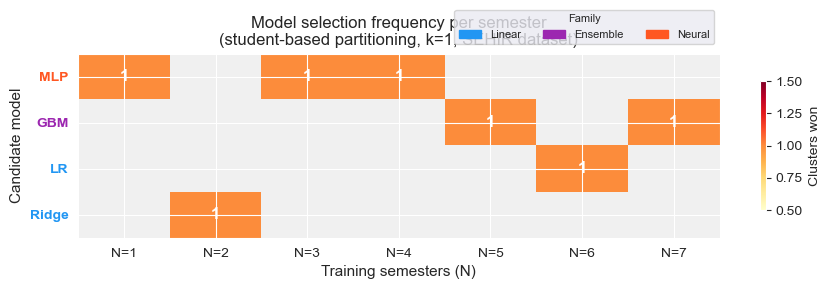

Figure A saved → fig_model_selection_heatmap_k1.pdf


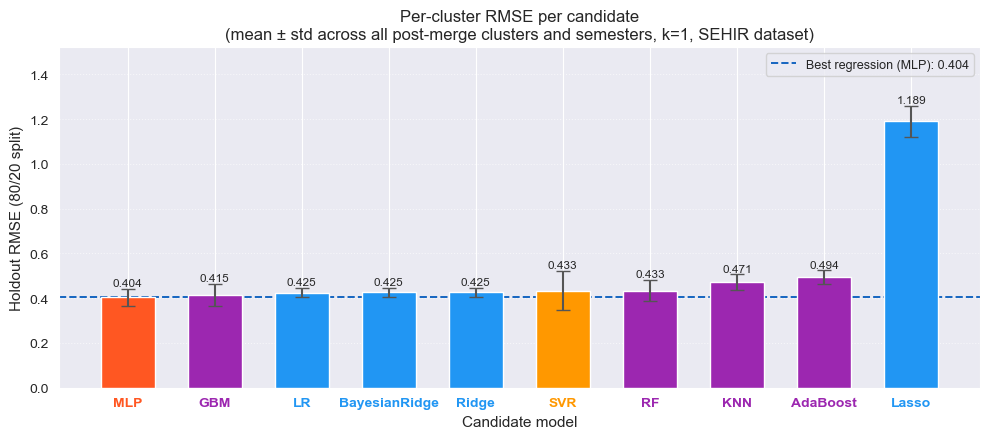

Figure B saved → fig_cv_rmse_per_candidate_k1.pdf
CF mean: nan

Winner distribution (7 cluster-semester pairs):
  MLP           :   3 (43%)
  GBM           :   2 (29%)
  Ridge         :   1 (14%)
  LR            :   1 (14%)

Suggested Observation 3:
  Collaborative Filtering was never selected as the best per-cluster model.
  MLP was chosen most frequently, winning 3/7 (43%) of (cluster, semester) pairs.
  The best regression candidate (MLP) achieved a mean holdout RMSE of 0.4036 vs nan for CF — a nan% gap — confirming that feature-based regression is the stronger predictor when students are properly segmented.

Per-model test performance (student-based partitioning, k=1, SEHIR dataset):
        Model     N  Test RMSE  Test MAE
BayesianRidge 35992     0.7872    0.5709
          MLP 35992     0.7872    0.5737
           LR 35992     0.7875    0.5713
        Ridge 35992     0.7901    0.5742
          GBM 35992     0.7976    0.5833
           RF 35992     0.8000    0.5837
     AdaBoost 35

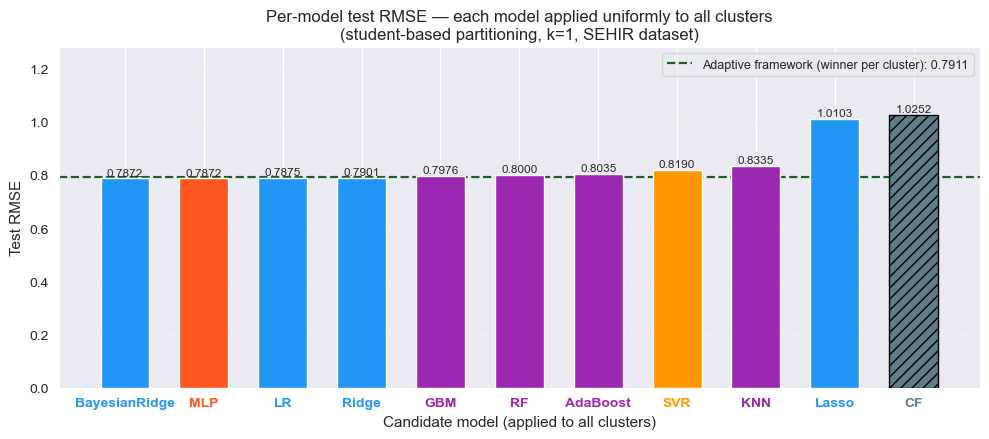

Figure C saved → fig_test_rmse_per_model_k1.pdf

Key finding:
  Best single model applied uniformly: BayesianRidge (RMSE=0.7872)
  Adaptive framework (per-cluster winner): RMSE=0.7911
  Adaptive framework vs best single model: -0.5% improvement
  CF applied uniformly: RMSE=1.0252 (worse than adaptive framework)


In [60]:
import matplotlib.patches as mpatches
from collections import defaultdict, Counter

K_VALUE = '1'

# ── Flatten cv_log across all semesters ──────────────────────────────────
selection_log = []  # list of {semester, cluster_id, winner, n, all_scores}
for sem_str, sem_data in reg_predictions_k1[K_VALUE].items():
    for clus_id, record in (sem_data.get('cv_log') or {}).items():
        selection_log.append({
            'semester':   int(sem_str),
            'cluster_id': int(clus_id),
            'winner':     record['winner'],
            'n':          record['n'],
            'all_scores': record['all_scores'],
        })

if not selection_log:
    print("No cv_log data found. Re-run Cell 28 first.")
else:
    print(f"Total (cluster, semester) pairs logged: {len(selection_log)}")

    # ── Colour / family map ──────────────────────────────────────────────
    FAMILY = {
        'Ridge':        'Linear', 'Lasso':        'Linear',
        'LR':           'Linear', 'BayesianRidge':'Linear',
        'SVR':          'Kernel',
        'RF':           'Ensemble', 'GBM':        'Ensemble',
        'AdaBoost':     'Ensemble', 'KNN':         'Ensemble',
        'MLP':          'Neural',
        'CF':           'CF',
    }
    FAMILY_COLOR = {
        'Linear':  '#2196F3', 'Kernel': '#FF9800',
        'Ensemble':'#9C27B0', 'Neural': '#FF5722', 'CF': '#607D8B',
    }
    MODEL_COLOR = {m: FAMILY_COLOR.get(f, '#AAAAAA') for m, f in FAMILY.items()}

    semesters  = sorted({r['semester']   for r in selection_log})
    all_models = sorted({r['winner']     for r in selection_log})

    # ── Figure A: Heatmap ─────────────────────────────────────────────────
    freq = pd.DataFrame(0, index=all_models, columns=semesters)
    for rec in selection_log:
        freq.loc[rec['winner'], rec['semester']] += 1

    row_order = sorted([m for m in all_models if m != 'CF'],
                       key=lambda m: freq.loc[m].sum(), reverse=True)
    if 'CF' in all_models:
        row_order.append('CF')
    freq = freq.loc[row_order]

    z      = freq.values.astype(float)
    z_plot = np.where(z == 0, np.nan, z)
    cmap   = plt.cm.YlOrRd
    cmap.set_bad('#F0F0F0')

    fig_a, ax_a = plt.subplots(figsize=(9, max(3, len(row_order) * 0.75)))
    im = ax_a.imshow(z_plot, cmap=cmap, aspect='auto',
                     vmin=0.5, vmax=max(z.max(), 1) + 0.5)

    for i, model in enumerate(row_order):
        for j, sem in enumerate(semesters):
            val = int(freq.loc[model, sem])
            if val > 0:
                color = 'white' if z_plot[i, j] >= z.max() * 0.6 else '#333333'
                ax_a.text(j, i, str(val), ha='center', va='center',
                          fontsize=12, fontweight='bold', color=color)

    ax_a.set_xticks(range(len(semesters)))
    ax_a.set_xticklabels([f'N={s}' for s in semesters], fontsize=10)
    ax_a.set_yticks(range(len(row_order)))
    ax_a.set_yticklabels(row_order, fontsize=10)
    for tick, model in zip(ax_a.get_yticklabels(), row_order):
        tick.set_color(FAMILY_COLOR.get(FAMILY.get(model, ''), '#333333'))
        tick.set_fontweight('bold')
    ax_a.set_xlabel('Training semesters (N)', fontsize=11)
    ax_a.set_ylabel('Candidate model', fontsize=11)
    ax_a.set_title(
        f'Model selection frequency per semester\n'
        f'(student-based partitioning, k={K_VALUE}, SEHIR dataset)',
        fontsize=12)
    plt.colorbar(im, ax=ax_a, label='Clusters won', shrink=0.7)
    patches = [mpatches.Patch(color=c, label=f)
               for f, c in FAMILY_COLOR.items()
               if any(FAMILY.get(m) == f for m in row_order)]
    ax_a.legend(handles=patches, title='Family', loc='lower right',
                bbox_to_anchor=(1.0, 1.02), ncol=len(patches),
                fontsize=8, title_fontsize=8)
    plt.tight_layout()
    plt.savefig(f'fig_model_selection_heatmap_k{K_VALUE}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure A saved → fig_model_selection_heatmap_k{K_VALUE}.pdf')

    # ── Figure B: CV-RMSE bar chart (cluster-size weighted) ───────────────
    # Each record carries 'n' (number of students in that cluster).
    # We weight each cluster's score by n so larger clusters contribute more.
    model_weighted = defaultdict(lambda: {'sum_wrmse': 0.0, 'sum_n': 0,
                                          'sq_resid': 0.0})
    for rec in selection_log:
        n = rec['n']
        for model_name, score in (rec['all_scores'] or {}).items():
            if score is not None and np.isfinite(score):
                model_weighted[model_name]['sum_wrmse'] += score * n
                model_weighted[model_name]['sum_n']     += n
                model_weighted[model_name]['sq_resid']  += (score ** 2) * n

    bar_df = pd.DataFrame([
        {
            'model': m,
            'mean':  v['sum_wrmse'] / v['sum_n'],
            # Weighted std: sqrt(E[x^2] - E[x]^2)
            'std':   np.sqrt(max(v['sq_resid'] / v['sum_n']
                                 - (v['sum_wrmse'] / v['sum_n']) ** 2, 0.0)),
        }
        for m, v in model_weighted.items()
    ]).sort_values('mean').reset_index(drop=True)
    colors = [MODEL_COLOR.get(m, '#AAAAAA') for m in bar_df['model']]

    fig_b, ax_b = plt.subplots(figsize=(10, 4.5))
    x    = np.arange(len(bar_df))
    bars = ax_b.bar(x, bar_df['mean'], yerr=bar_df['std'],
                    color=colors,
                    error_kw=dict(elinewidth=1.5, capsize=5, ecolor='#555555'),
                    zorder=3, width=0.62)

    if 'CF' in bar_df['model'].values:
        cf_i = bar_df[bar_df['model'] == 'CF'].index[0]
        bars[cf_i].set_hatch('///')
        bars[cf_i].set_edgecolor('black')

    for i, row in bar_df.iterrows():
        ax_b.text(i, row['mean'] + row['std'] + 0.003,
                  f"{row['mean']:.3f}", ha='center', va='bottom', fontsize=8.5)

    best_reg = bar_df[bar_df['model'] != 'CF'].iloc[0]
    ax_b.axhline(best_reg['mean'], color='#1565C0', linestyle='--',
                 linewidth=1.4, zorder=2,
                 label=f"Best regression ({best_reg['model']}): {best_reg['mean']:.3f}")

    ax_b.set_xticks(x)
    ax_b.set_xticklabels(bar_df['model'], fontsize=10)
    for tick, model in zip(ax_b.get_xticklabels(), bar_df['model']):
        tick.set_color(FAMILY_COLOR.get(FAMILY.get(model, ''), '#333333'))
        tick.set_fontweight('bold')
    ax_b.set_ylabel('Holdout RMSE (80/20 split)', fontsize=11)
    ax_b.set_xlabel('Candidate model', fontsize=11)
    ax_b.set_title(
        f'Per-cluster RMSE per candidate\n'
        f'(mean \u00b1 std across all post-merge clusters and semesters, '
        f'k={K_VALUE}, SEHIR dataset)',
        fontsize=12)
    ax_b.set_ylim(0, bar_df['mean'].max() * 1.28)
    ax_b.yaxis.grid(True, linestyle=':', alpha=0.6, zorder=0)
    ax_b.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'fig_cv_rmse_per_candidate_k{K_VALUE}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure B saved → fig_cv_rmse_per_candidate_k{K_VALUE}.pdf')

    # ── Observation 3 narrative ───────────────────────────────────────────
    winner_counts = Counter(r['winner'] for r in selection_log)
    total         = len(selection_log)
    top_model, top_n = winner_counts.most_common(1)[0]
    cf_entry  = model_weighted.get('CF', {})
    cf_mean   = (cf_entry['sum_wrmse'] / cf_entry['sum_n']
                 if cf_entry.get('sum_n', 0) > 0 else float('nan'))
    print(f"CF mean: {cf_mean:.3f}")
    best_mean     = best_reg['mean']
    gap_pct       = (cf_mean - best_mean) / cf_mean * 100 if cf_mean > 0 else float('nan')

    print(f"\nWinner distribution ({total} cluster-semester pairs):")
    for m, n in winner_counts.most_common():
        print(f"  {m:14s}: {n:3d} ({n/total*100:.0f}%)")
    print(f"\nSuggested Observation 3:")
    print(
        f"  Collaborative Filtering was never selected as the best per-cluster model.\n"
        f"  {top_model} was chosen most frequently, winning "
        f"{top_n}/{total} ({top_n/total*100:.0f}%) of (cluster, semester) pairs.\n"
        f"  The best regression candidate ({best_reg['model']}) achieved a mean holdout RMSE "
        f"of {best_mean:.4f} vs {cf_mean:.4f} for CF — "
        f"a {gap_pct:.1f}% gap — confirming that feature-based regression is the "
        f"stronger predictor when students are properly segmented."
    )


# ═══════════════════════════════════════════════════════════════════════════
# Test-performance comparison: per-model RMSE and MAE on actual test data
# ═══════════════════════════════════════════════════════════════════════════

# Flatten y_preds across all semesters into per-model lists
test_true_per_model = defaultdict(list)
test_pred_per_model = defaultdict(list)

for sem_str, sem_data in reg_predictions_k1[K_VALUE].items():
    for m_name, m_data in sem_data.get('y_preds', {}).items():
        test_true_per_model[m_name].extend(m_data['y_true'])
        test_pred_per_model[m_name].extend(m_data['y_pred'])

if not test_true_per_model:
    print("No y_preds data found. Re-run Cell 28 with the updated code.")
else:
    perf_rows = []
    for m_name in sorted(test_pred_per_model):
        yt = test_true_per_model[m_name]
        yp = test_pred_per_model[m_name]
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae  = mean_absolute_error(yt, yp)
        perf_rows.append({'Model': m_name, 'N': len(yt),
                          'Test RMSE': round(rmse, 4),
                          'Test MAE':  round(mae,  4)})

    perf_df = pd.DataFrame(perf_rows).sort_values('Test RMSE').reset_index(drop=True)
    print("\nPer-model test performance (student-based partitioning, "
          f"k={K_VALUE}, SEHIR dataset):")
    print(perf_df.to_string(index=False))

    # ── Figure C: Test RMSE bar chart ──────────────────────────────────────
    fig_c, ax_c = plt.subplots(figsize=(10, 4.5))
    x_c     = np.arange(len(perf_df))
    colors_c = [MODEL_COLOR.get(m, '#AAAAAA') for m in perf_df['Model']]
    bars_c  = ax_c.bar(x_c, perf_df['Test RMSE'], color=colors_c,
                        zorder=3, width=0.62)

    # Hatch CF bar
    if 'CF' in perf_df['Model'].values:
        cf_i = perf_df[perf_df['Model'] == 'CF'].index[0]
        bars_c[cf_i].set_hatch('///')
        bars_c[cf_i].set_edgecolor('black')

    # Annotate bar tops
    for i, row in perf_df.iterrows():
        ax_c.text(i, row['Test RMSE'] + 0.003, f"{row['Test RMSE']:.4f}",
                  ha='center', va='bottom', fontsize=8.5)

    # Reference line: adaptive framework (winner model) overall RMSE
    from sklearn.metrics import mean_squared_error as _mse
    all_yt = predictions[K_VALUE][list(predictions[K_VALUE].keys())[-1]]['y_true'] if False else []
    # Use the already-computed adaptive RMSE from compute_overall_metrics
    adaptive_rmse, _ = compute_overall_metrics(reg_predictions_k1, k_value=K_VALUE)
    ax_c.axhline(adaptive_rmse, color='#1B5E20', linestyle='--', linewidth=1.6,
                 zorder=2, label=f'Adaptive framework (winner per cluster): {adaptive_rmse:.4f}')

    ax_c.set_xticks(x_c)
    ax_c.set_xticklabels(perf_df['Model'], fontsize=10)
    for tick, model in zip(ax_c.get_xticklabels(), perf_df['Model']):
        tick.set_color(FAMILY_COLOR.get(FAMILY.get(model, ''), '#333333'))
        tick.set_fontweight('bold')
    ax_c.set_ylabel('Test RMSE', fontsize=11)
    ax_c.set_xlabel('Candidate model (applied to all clusters)', fontsize=11)
    ax_c.set_title(
        f'Per-model test RMSE — each model applied uniformly to all clusters\n'
        f'(student-based partitioning, k={K_VALUE}, SEHIR dataset)',
        fontsize=12)
    ax_c.set_ylim(0, perf_df['Test RMSE'].max() * 1.25)
    ax_c.yaxis.grid(True, linestyle=':', alpha=0.6, zorder=0)
    ax_c.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'fig_test_rmse_per_model_k{K_VALUE}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure C saved → fig_test_rmse_per_model_k{K_VALUE}.pdf')

    # ── Summary observation ────────────────────────────────────────────────
    best_single = perf_df.iloc[0]
    worst_single = perf_df.iloc[-1]
    adaptive_row = perf_df[perf_df['Model'] == 'adaptive'] if False else None

    print(f"\nKey finding:")
    print(f"  Best single model applied uniformly: {best_single['Model']} "
          f"(RMSE={best_single['Test RMSE']:.4f})")
    print(f"  Adaptive framework (per-cluster winner): RMSE={adaptive_rmse:.4f}")
    gap = (best_single['Test RMSE'] - adaptive_rmse) / best_single['Test RMSE'] * 100
    print(f"  Adaptive framework vs best single model: {gap:.1f}% improvement")
    if 'CF' in perf_df['Model'].values:
        cf_rmse = perf_df[perf_df['Model'] == 'CF']['Test RMSE'].values[0]
        print(f"  CF applied uniformly: RMSE={cf_rmse:.4f} "
              f"({'worse' if cf_rmse > adaptive_rmse else 'better'} than adaptive framework)")


In [58]:
# ── Coverage breakdown by prediction tier ─────────────────────────────────
analyze_coverage_and_rmse_gap(reg_predictions, k_value='15')

NameError: name 'reg_predictions' is not defined

In [175]:
# ── Run baseline for comparison ───────────────────────────────────────────
RUN_BASELINE = False
if RUN_BASELINE:
    baseline_results = predict_baseline(recommendations.sim_distance, item_based=True)

In [96]:
# ── Verify prediction count parity ───────────────────────────────────────
baseline_n = len(baseline_results['y_true'])
diagnose_prediction_count(reg_predictions, baseline_n, k_value='15')

Adaptive predicted: 35,992
Baseline predicted: 35,962
Difference:         30
✅ Counts are within expected range (outlier filter difference).


In [97]:
# ── Save results ──────────────────────────────────────────────────────────
with open('adaptive_regression_results_student_based_KMeans.json', 'w') as fw:
    # Convert numpy types to native Python for JSON serialization
    def to_serializable(obj):
        if isinstance(obj, dict):
            return {k: to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [to_serializable(i) for i in obj]
        elif isinstance(obj, (np.integer,)):
            return int(obj)
        elif isinstance(obj, (np.floating,)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return obj
    json.dump(to_serializable(reg_predictions), fw)
print("Results saved.")

Results saved.


In [128]:
DEBUG = False

if DEBUG:
    def compare_semester_grade_distributions():
        sorted_semesters = sorted(set(df.iloc[:, 3]))
        for sem_idx in range(1, len(sorted_semesters)):
            sem_name = sorted_semesters[sem_idx]
            sem_data = get_semester_data(sem_name)
            grades   = [g for student in sem_data.values() for g in student.values()]
            print(f"Sem {sem_idx} ({sem_name}): "
                  f"N={len(grades):,}  "
                  f"mean={np.mean(grades):.3f}  "
                  f"std={np.std(grades):.3f}  "
                  f"min={np.min(grades):.1f}  "
                  f"max={np.max(grades):.1f}")

    compare_semester_grade_distributions()

    def analyze_sem6_residuals(predictions_dict, k_value='15', sem_idx='6'):
        sem_data = predictions_dict[k_value][sem_idx]
        y_true   = np.array(sem_data['y_true'])
        y_pred   = np.array(sem_data['y_pred'])
        residuals = y_true - y_pred

        print(f"Sem 6 residual stats:")
        print(f"  Mean residual:   {np.mean(residuals):.4f}  (bias — positive = underpredicting)")
        print(f"  Std  residual:   {np.std(residuals):.4f}")
        print(f"  |residual| > 2:  {(np.abs(residuals) > 2).sum()} instances")
        print(f"  |residual| > 1:  {(np.abs(residuals) > 1).sum()} instances")
        print()

        # Grade-bucket breakdown — where is the error concentrated?
        buckets = [(0.0, 1.0, 'F–D'), (1.0, 2.0, 'D–C'), (2.0, 3.0, 'C–B'), (3.0, 4.1, 'B–A')]
        print(f"  {'Grade range':<12} {'N':>6} {'RMSE':>8} {'mean_resid':>12}")
        print(f"  {'-'*40}")
        for lo, hi, label in buckets:
            idx = np.where((y_true >= lo) & (y_true < hi))[0]
            if len(idx) == 0:
                continue
            rmse = np.sqrt(mean_squared_error(y_true[idx], y_pred[idx]))
            bias = np.mean(y_true[idx] - y_pred[idx])
            print(f"  {label:<12} {len(idx):>6} {rmse:>8.4f} {bias:>12.4f}")

    analyze_sem6_residuals(reg_predictions)

    def analyze_sem6_cluster_breakdown(predictions_dict, k_value='15', sem_idx='6'):
        """
        If sources were tracked per-cluster, break RMSE down by cluster.
        Since we don't store cluster_label per prediction, proxy via
        comparing Sem 5 and Sem 6 model winner performance directly.
        """
        for target_sem, label in [('5', 'Sem 5'), ('6', 'Sem 6'), ('7', 'Sem 7')]:
            sem_data = predictions_dict[k_value][target_sem]
            y_true   = np.array(sem_data['y_true'])
            y_pred   = np.array(sem_data['y_pred'])
            rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
            bias     = np.mean(y_true - y_pred)
            print(f"{label}: RMSE={rmse:.4f}  bias={bias:.4f}  N={len(y_true):,}")

    analyze_sem6_cluster_breakdown(reg_predictions)

    def failing_rate_per_semester():
        sorted_semesters = sorted(set(df.iloc[:, 3]))
        print(f"{'Sem':<5} {'Name':<20} {'Total':>7} {'F+D count':>10} {'F+D %':>8} {'F+D- count':>10} {'F+D- %':>8} {'F count':>10} {'F %':>8}")
        print('-' * 55)
        for sem_idx in range(1, len(sorted_semesters)):
            sem_name = sorted_semesters[sem_idx]
            sem_data = get_semester_data(sem_name)
            grades   = [g for student in sem_data.values() for g in student.values()]
            F_grades  = [g for g in grades if g == 0.0]   # F = 0.0
            failing  = [g for g in grades if g < 1.0]   # F = 0.0, D- = 0.5
            low      = [g for g in grades if g < 1.4]   # F + D range
            print(f"{sem_idx:<5} {sem_name:<20} {len(grades):>7} "
                  f"{len(low):>10} {len(low)/len(grades)*100:>7.1f}%"
                  f"{len(failing):>10} {len(failing)/len(grades)*100:>7.1f}%"
                  f"{len(F_grades):>10} {len(F_grades)/len(grades)*100:>7.1f}%")

    failing_rate_per_semester()

    def compare_model_on_sem6(predictions_dict, k_value='15'):
        """
        Retrospectively check: would MLP have done better on Sem 6 test data?
        Refit MLP on the same Sem 6 training data and evaluate on the actual
        Sem 6 test predictions we already have stored.
        Since we don't store cluster assignments, we test at the semester level
        using the global training data.
        """
        from sklearn.neural_network import MLPRegressor

        sorted_semesters = sorted(set(df.iloc[:, 3]))
        train_sems = sorted_semesters[:6]   # training semesters for sem_idx=6
        test_sem   = sorted_semesters[6]

        X_train, y_train = get_reg_train_data(train_sems)
        X_test,  y_test  = get_reg_train_data([test_sem])

        sc = StandardScaler()
        X_tr_std  = sc.fit_transform(X_train)
        X_te_std  = sc.transform(X_test)

        candidates = {
            'LR':  LinearRegression(),
            'SVR': SVR(C=tuned_hyperparams_reg['SVR']['C'],
                       kernel=tuned_hyperparams_reg['SVR']['kernel'],
                       epsilon=tuned_hyperparams_reg['SVR']['epsilon']),
            'MLP': MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
            'Ridge': Ridge(alpha=tuned_hyperparams_reg['Ridge']['alpha']),
        }

        print(f"Global model comparison on Sem 6 test data:")
        print(f"  Train N: {len(X_train):,}  |  Test N: {len(X_test):,}")
        print()
        for name, m in candidates.items():
            m.fit(X_tr_std, y_train)
            preds = m.predict(X_te_std)
            rmse  = np.sqrt(mean_squared_error(y_test, preds))
            print(f"  {name:<8} RMSE: {rmse:.4f}")

    compare_model_on_sem6(reg_predictions)

Sem 1 (2011 - Spring): N=1,810  mean=2.783  std=1.172  min=0.0  max=4.1
Sem 2 (2012 - Fall): N=3,842  mean=2.599  std=1.261  min=0.0  max=4.1
Sem 3 (2012 - Spring): N=4,263  mean=2.667  std=1.249  min=0.0  max=4.1
Sem 4 (2013 - Fall): N=7,075  mean=2.550  std=1.249  min=0.0  max=4.1
Sem 5 (2013 - Spring): N=7,668  mean=2.493  std=1.269  min=0.0  max=4.1
Sem 6 (2014 - Fall): N=11,133  mean=2.500  std=1.249  min=0.0  max=4.1
Sem 7 (2014 - Spring): N=10,647  mean=2.604  std=1.224  min=0.0  max=4.1
Sem 6 residual stats:
  Mean residual:   -0.0931  (bias — positive = underpredicting)
  Std  residual:   0.8967
  |residual| > 2:  277 instances
  |residual| > 1:  1546 instances

  Grade range       N     RMSE   mean_resid
  ----------------------------------------
  F–D             984   1.7480      -1.6043
  D–C            1181   0.8573      -0.6394
  C–B            2079   0.5828      -0.0870
  B–A            3536   0.7022       0.4272
Sem 5: RMSE=0.7778  bias=-0.1168  N=6,724
Sem 6: RMSE=0.9

In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the recorded JSON data
filename = 'reg_predictions_k10_ANHUI.json'
try:
    with open(filename, 'r') as f:
        data = json.load(f)
except FileNotFoundError:
    print(f"Error: {filename} not found. Please ensure the file is in the correct directory.")
    exit()

# Assuming k=10 as specified by the user, we filter for cluster keys from 0 to 9.
num_clusters = 10
cluster_keys = [f"Cluster_{i}" for i in range(num_clusters)]

# Extract and process data for performance metrics
performance_metrics = []
for cluster_key in cluster_keys:
    if cluster_key in data:
        cluster_data = data[cluster_key]
        for model_name, folds_results in cluster_data.items():
            # Calculate average CV-RMSE for each model within the cluster
            avg_cv_rmse = np.mean(folds_results)
            performance_metrics.append({
                'Cluster ID': cluster_key,
                'Candidate Model': model_name,
                'Average CV-RMSE': avg_cv_rmse
            })

# Create a DataFrame
df = pd.DataFrame(performance_metrics)

# Check if data was loaded correctly
if df.empty:
    print("Error: No data extracted from the JSON for the specified clusters. Please check the JSON format.")
    exit()

# Pivot data for heatmap: Clusters as rows, Models as columns
df_heatmap = df.pivot(index='Cluster ID', columns='Candidate Model', values='Average CV-RMSE')

# Get sorted model names for consistency across plots
model_names = sorted(df_heatmap.columns)
df_heatmap = df_heatmap[model_names]
# Ensure clusters are in numerical order
df_heatmap = df_heatmap.reindex(cluster_keys)

# --- 1. Generate the Heatmap ---
plt.figure(figsize=(14, 8))
# Using a reversed colormap so lower RMSE (better performance) is darker/more prominent
sns.heatmap(df_heatmap, annot=True, cmap="YlGnBu_r", fmt=".4f", cbar_kws={'label': 'Average CV-RMSE'})
plt.title('CV-RMSE Heatmap per Cluster and Model (ANHUI Dataset, k=10)', fontsize=16)
plt.ylabel('Cluster ID', fontsize=14)
plt.xlabel('Candidate Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save figure at 300 DPI for publication
plt.savefig('heatmap_cv_rmse_k10.png', dpi=300, bbox_inches='tight')
print("Saved: heatmap_cv_rmse_k10.png")
plt.show() # Display the heatmap

# --- 2. Generate Figure CV-RMSE per candidate, averaged over clusters ---
# Group by model and calculate overall average RMSE across all clusters
avg_model_performance = df.groupby('Candidate Model')['Average CV-RMSE'].mean()

# Order the series by model names for consistent ordering
avg_model_performance = avg_model_performance.reindex(model_names)

plt.figure(figsize=(12, 6))
# Create bar plot
bar_plot = sns.barplot(x=avg_model_performance.index, y=avg_model_performance.values, palette="viridis", order=model_names)
plt.title('CV-RMSE per Candidate Model, Averaged over Clusters (ANHUI Dataset, k=10)', fontsize=16)
plt.ylabel('Averaged CV-RMSE', fontsize=14)
plt.xlabel('Candidate Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save figure at 300 DPI for publication
plt.savefig('barplot_cv_rmse_k10.png', dpi=300, bbox_inches='tight')
print("Saved: barplot_cv_rmse_k10.png")
plt.show() # Display the bar chart

Error: No data extracted from the JSON for the specified clusters. Please check the JSON format.


KeyError: 'Cluster ID'